# Разработка решения для персонализации предложения постоянным клиентам с целью увеличения их покупательской активности для интернет-магазина «В один клик»

Интернет-магазин «В один клик» продаёт следующие группы товаров:

- товары для детей,
- товары для дома,
- мелкая бытовая техника,
- косметика,
- продукты.

Отчёт магазина за прошлый период показал, что активность покупателей начала снижаться. Привлекать новых клиентов уже не так эффективно: о магазине и так знает большая часть целевой аудитории. Возможный выход — удерживать активность постоянных клиентов. Сделать это можно с помощью персонализированных предложений.

**«В один клик»** — современная компания. По этой причине её руководство не хочет принять решения на основе анализа данных и бизнес-моделирования. 

Необходимо разработать решение, которое позволит персонализировать предложения постоянным клиентам, чтобы увеличить их покупательскую активность.

**Формирование задачи**

1. Маркировка уровеня финансовой активности постоянных покупателей. В компании принято выделять два уровня активности: «снизилась», если клиент стал покупать меньше товаров, и «прежний уровень».
2. Сбор данных по клиентам по следующим группам:

  - Признаки, которые описывают коммуникацию сотрудников компании с клиентом.
  - Признаки, которые описывают продуктовое поведение покупателя.
  - Признаки, которые описывают покупательское поведение клиента.
  - Признаки, которые описывают поведение покупателя на сайте.

Группы признаков (вместе с целевым) в виде диаграммы представлен ниже посредством диаграммы Исикавы.

<img src="https://pictures.s3.yandex.net:443/resources/image_1695893699.png" alt="" crossorigin="anonymous" class="image image_expandable" style="">

3. Построение модели, которая предскажет вероятность снижения покупательской активности клиента в следующие три месяца.
4. Включение в исследование дополнительных данных финансового департамента о прибыльности клиента (доход каждый покупатель приносил компании за последние три месяца).
5. Выделение сегменты покупателей и разработка для них персонализированные предложения, используя данные модели и данные о прибыльности клиентов.

**Этапы исследования**

1. Разработка модели, которая предскажет вероятность снижения покупательской активности.
2. Выделеление сегмента покупателей, его анализ и составление предложений, как увеличить его покупательскую активность.

**План исследования**

1. Загрузка и предобработка данных
2. Исследовательский анализ данных
3. Объединение таблиц `market_file.csv`, `market_money.csv`, `market_time.csv`
4. Корреляционный анализ
5. Использование пайплайнов
6. Анализ важности признаков
7. Сегментация покупателей
8. Общий вывод

**Описание данных**

Данные для работы находятся в нескольких таблицах:

- `market_file.csv`
- `market_money.csv`
- `market_time.csv`
- `money.csv`

Таблица `market_file.csv` содержит данные о поведении покупателя на сайте, о коммуникациях с покупателем и его продуктовом поведении.

|                                     |                                                                                                                                                                                                                               |
|-------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **id**                                  | номер покупателя в корпоративной базе данных                                                                                                                                                                                  |
| **Покупательская активность**           | рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень»                                                                                                                             |
| **Тип сервиса**                         | уровень сервиса, например «премиум» и «стандарт»                                                                                                                                                                              |
| **Разрешить сообщать**                  | информация о том, можно ли присылать покупателю дополнительные предложения о товаре (cогласие на это даёт покупатель)                                                                                                         |
| **Маркет актив 6 мес**                  | среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)  |
| **Маркет актив тек мес**                | количество маркетинговых коммуникаций в текущем месяце                                                                                                                                                                        |
| **Длительность**                        | значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте                                                                                                                                   |
| **Акционные покупки**                   | среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев                                                                                                                                           |
| **Популярная_категория**                | самая популярная категория товаров у покупателя за последние 6 месяцев                                                                                                                                                        |
| **Средний просмотр категорий за визит** | показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца                                                                                                                            |
| **Неоплаченные продукты штук квартал**  | общее число неоплаченных товаров в корзине за последние 3 месяца                                                                                                                                                              |
| **Ошибка_сервиса**                      | число сбоев, которые коснулись покупателя во время посещения сайта                                                                                                                                                            |
| **Страниц за визит**                    | среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца                                                                                                                         |


Таблица `market_money.csv` содержит данные о выручке, которую получает магазин с покупателя, то есть сколько покупатель всего потратил за период взаимодействия с сайтом.

|         |                                                            |
|---------|------------------------------------------------------------|
| **id**      | номер покупателя в корпоративной базе данных               |
| **Период**  | название периода, во время которого зафиксирована выручка  |
| **Выручка** | сумма выручки за период                                    |

Таблица `market_time.csv` содержит данные о времени (в минутах), которое покупатель провёл на сайте в течение периода.

|        |                                                                |
|--------|----------------------------------------------------------------|
| **id**     | номер покупателя в корпоративной базе данных                   |
| **Период** | название периода, во время которого зафиксировано общее время  |
| **минут**  | значение времени, проведённого на сайте, в минутах             |

Таблица `money.csv` содержит данные о среднемесячной прибыли покупателя за последние 3 месяца: какую прибыль получает магазин от продаж каждому покупателю.

|         |                                               |
|---------|-----------------------------------------------|
| **id**      | номер покупателя в корпоративной базе данных  |
| **Прибыль** | значение прибыли                              |


## Шаг. Загрузка и предобработка данных

In [1]:
!pip install --upgrade scikit-learn -q
!pip install matplotlib==3.5.1
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns
!pip install phik -q
import phik 
from phik import phik_matrix
from phik.report import plot_correlation_matrix
RANDOM_STATE = 42
TEST_SIZE = 0.25
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder,\
StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_selection import SelectKBest, f_classif
from numpy import array 
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
!pip install shap -q
import sklearn
import shap
import random

     |████████████████████████████████| 11.2 MB 1.3 MB/s eta 0:00:01
     |████████████████████████████████| 4.7 MB 33.3 MB/s eta 0:00:01
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.3.4
    Uninstalling matplotlib-3.3.4:
      Successfully uninstalled matplotlib-3.3.4


In [2]:
#считаем csv - файл с данными `market_file.csv`
try:
    market_file = pd.read_csv('market_file.csv')
except:
    market_file = pd.read_csv('https://code.s3.yandex.net/datasets/market_file.csv')

#считаем csv - файл с данными `market_money.csv`
try:
    market_money = pd.read_csv('market_money.csv')
except:
    market_money = pd.read_csv('https://code.s3.yandex.net/datasets/market_money.csv')
    
#считаем csv - файл с данными `market_time.csv`
try:
    market_time = pd.read_csv('market_time.csv')
except:
    market_time = pd.read_csv('https://code.s3.yandex.net/datasets/market_time.csv')
    
#считаем csv - файл с данными `money.csv`
try:
    money = pd.read_csv('money.csv')
except:
    money = pd.read_csv('https://code.s3.yandex.net/datasets/money.csv', sep=';', decimal = ',')

In [3]:
def desc_data(data):
    data.columns = map(str.lower, data.columns)
    data.columns = data.columns.str.lower().str.replace(' ', '_')
    display(data.head(10)) 
    list_c = data.columns
    print(data.info())
    print('-'* 25)
    print('Количество полных дубликатов ', data.duplicated().sum())
    for col_l in list_c:
        print('-'* 25)
        print(col_l,': кол-во NaN',data[col_l].isna().sum(),\
              ', процент NaN', round(data[col_l].isna().mean()*100,2),'%')
        print(data[col_l].describe())

### Предобработка данных для датасета 'market_file'

In [4]:
desc_data(market_file)

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
0,215348,Снизилась,премиум,да,3.4,5,121,0.00,Товары для детей,6,2,1,5
1,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5
2,215350,Снизилась,стандартт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5
3,215351,Снизилась,стандартт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4
4,215352,Снизилась,стандартт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2
5,215353,Снизилась,стандартт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4
6,215354,Снизилась,стандартт,да,5.1,3,431,0.23,Косметика и аксесуары,2,3,7,2
7,215355,Снизилась,стандартт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4
8,215356,Снизилась,стандартт,да,4.2,4,192,0.14,Косметика и аксесуары,2,2,1,3
9,215357,Снизилась,стандартт,да,3.9,5,154,0.00,Техника для красоты и здоровья,3,3,9,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   id                                   1300 non-null   int64  
 1   покупательская_активность            1300 non-null   object 
 2   тип_сервиса                          1300 non-null   object 
 3   разрешить_сообщать                   1300 non-null   object 
 4   маркет_актив_6_мес                   1300 non-null   float64
 5   маркет_актив_тек_мес                 1300 non-null   int64  
 6   длительность                         1300 non-null   int64  
 7   акционные_покупки                    1300 non-null   float64
 8   популярная_категория                 1300 non-null   object 
 9   средний_просмотр_категорий_за_визит  1300 non-null   int64  
 10  неоплаченные_продукты_штук_квартал   1300 non-null   int64  
 11  ошибка_сервиса                

| Показатель                          | Описание                                                                                                                                                                                                                     | Формат  | Примечание               |
|-------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|---------|--------------------------|
| **id**                                  | номер покупателя в корпоративной базе данных                                                                                                                                                                                 | int64   | Формат данных оптимален  |
| **покупательская_активность**           | рассчитанный класс покупательской активности (целевой признак): «снизилась» или «прежний уровень»                                                                                                                            | object  | Формат данных оптимален  |
| **тип_сервиса**                         | уровень сервиса, например «премиум» и «стандарт»                                                                                                                                                                             | object  | Формат данных оптимален  |
| **разрешить_сообщать**                  | информация о том, можно ли присылать покупателю дополнительные предложения о товаре (cогласие на это даёт покупатель)                                                                                                        | object  | Формат данных оптимален  |
| **маркет_ актив_ 6_ мес**                  | среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента) | float64 | Формат данных оптимален  |
| **маркет_актив_тек_мес**                | количество маркетинговых коммуникаций в текущем месяце                                                                                                                                                                       | int64   | Формат данных оптимален  |
| **длительность**                        | значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте                                                                                                                                  | int64   | Формат данных оптимален  |
| **акционные_покупки**                   | среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев                                                                                                                                          | float64 | Формат данных оптимален  |
| **популярная_категория**                | самая популярная категория товаров у покупателя за последние 6 месяцев                                                                                                                                                       | object  | Формат данных оптимален  |
| **средний_просмотр_категорий_за_визит** | показывает, сколько в среднем категорий покупатель просмотрел за визит в течение последнего месяца                                                                                                                           | int64   | Формат данных оптимален  |
| **неоплаченные_продукты_штук_квартал**  | общее число неоплаченных товаров в корзине за последние 3 месяца                                                                                                                                                             | int64   | Формат данных оптимален  |
| **ошибка_сервиса**                      | число сбоев, которые коснулись покупателя во время посещения сайта                                                                                                                                                           | int64   | Формат данных оптимален  |
| **страниц_за_визит**                    | среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца                                                                                                                        | int64   | Формат данных оптимален  |


Проверим уникальные значения для категориальных признаков.

In [5]:
def unique_znach(data):
    list_c = data.select_dtypes(include='object').columns.tolist()
    for i in list_c:
        print('Уникальные значения для столбца "',i,'" :')
        print(data[i].unique())
        print('-'* 25)

In [6]:
unique_znach(market_file)

Уникальные значения для столбца " покупательская_активность " :
['Снизилась' 'Прежний уровень']
-------------------------
Уникальные значения для столбца " тип_сервиса " :
['премиум' 'стандартт' 'стандарт']
-------------------------
Уникальные значения для столбца " разрешить_сообщать " :
['да' 'нет']
-------------------------
Уникальные значения для столбца " популярная_категория " :
['Товары для детей' 'Домашний текстиль' 'Косметика и аксесуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']
-------------------------


Заменим значение 'стандартт' на 'стандарт', 'аксесуары' - на 'аксессуары'.

In [7]:
market_file['тип_сервиса'] = market_file['тип_сервиса'].replace('стандартт','стандарт')
market_file['популярная_категория'] = market_file['популярная_категория'].\
replace('Косметика и аксесуары','Косметика и аксессуары')

In [8]:
unique_znach(market_file)

Уникальные значения для столбца " покупательская_активность " :
['Снизилась' 'Прежний уровень']
-------------------------
Уникальные значения для столбца " тип_сервиса " :
['премиум' 'стандарт']
-------------------------
Уникальные значения для столбца " разрешить_сообщать " :
['да' 'нет']
-------------------------
Уникальные значения для столбца " популярная_категория " :
['Товары для детей' 'Домашний текстиль' 'Косметика и аксессуары'
 'Техника для красоты и здоровья' 'Кухонная посуда'
 'Мелкая бытовая техника и электроника']
-------------------------


In [9]:
print('Количество дубликатов после внесения изменений: ',market_file.duplicated().sum())

Количество дубликатов после внесения изменений:  0


### Предобработка данных для датасета 'market_money'

In [10]:
desc_data(market_money)

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
1,215348,текущий_месяц,3293.1
2,215348,предыдущий_месяц,0.0
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       3900 non-null   int64  
 1   период   3900 non-null   object 
 2   выручка  3900 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 91.5+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      3900.000000
mean     215997.500000
std         375.325686
min      215348.000000
25%      215672.750000
50%      215997.500000
75%      216322.250000
max      216647.000000
Name: id, dtype: float64
-------------------------
период : кол-во NaN 0 , процент NaN 0.0 %
count              3900
unique                3
top       текущий_месяц
freq               1300
Name: период, dtype: object
-------------------------
выручка : кол-во NaN 0 , процент NaN 0.0 %
count      3900.000000
mean       5025.69605

| Показатель | Описание                                                  | Формат  | Примечание               |
|------------|-----------------------------------------------------------|---------|--------------------------|
| **id**         | номер покупателя в корпоративной базе данных              | int64   | Формат данных оптимален  |
| **период**     | название периода, во время которого зафиксирована выручка | object  | Формат данных оптимален  |
| **выручка**    | сумма выручки за период                                   | float64 | Формат данных оптимален  

In [11]:
unique_znach(market_money)

Уникальные значения для столбца " период " :
['препредыдущий_месяц' 'текущий_месяц' 'предыдущий_месяц']
-------------------------


In [12]:
display(market_money['период'].value_counts())

текущий_месяц          1300
предыдущий_месяц       1300
препредыдущий_месяц    1300
Name: период, dtype: int64

**Делается вывод, что в датасете `market_money` данные представлены по каждому клиенту за отдельный период в отдельной строке. При объединении таблиц это необходимо будет учесть.**

### Предобработка данных для датасета 'market_time'

In [13]:
desc_data(market_time)

,id,период,минут
0,215348,текущий_месяц,14
1,215348,предыдцщий_месяц,13
2,215349,текущий_месяц,10
3,215349,предыдцщий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдцщий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдцщий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдцщий_месяц,8


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2600 entries, 0 to 2599
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2600 non-null   int64 
 1   период  2600 non-null   object
 2   минут   2600 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 61.1+ KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      2600.000000
mean     215997.500000
std         375.349754
min      215348.000000
25%      215672.750000
50%      215997.500000
75%      216322.250000
max      216647.000000
Name: id, dtype: float64
-------------------------
период : кол-во NaN 0 , процент NaN 0.0 %
count              2600
unique                2
top       текущий_месяц
freq               1300
Name: период, dtype: object
-------------------------
минут : кол-во NaN 0 , процент NaN 0.0 %
count    2600.000000
mean       13.336154
std         4.080198
min  

| Показатель | Описание                                                      | Формат | Примечание               |
|------------|---------------------------------------------------------------|--------|--------------------------|
| **id**         | номер покупателя в корпоративной базе данных                  | int64  | Формат данных оптимален  |
| **период**     | название периода, во время которого зафиксировано общее время | object | Формат данных оптимален  |
| **минут**      | значение времени, проведённого на сайте, в минутах            | int64  | Формат данных оптимален  |


In [14]:
unique_znach(market_time)

Уникальные значения для столбца " период " :
['текущий_месяц' 'предыдцщий_месяц']
-------------------------


Заменим значение 'предыдцщий_месяц' на 'предыдущий_месяц'.

In [15]:
market_time['период'] = market_time['период'].replace('предыдцщий_месяц','предыдущий_месяц')

In [16]:
unique_znach(market_time)

Уникальные значения для столбца " период " :
['текущий_месяц' 'предыдущий_месяц']
-------------------------


In [17]:
print('Количество дубликатов после внесения изменений: ',market_time.duplicated().sum())

Количество дубликатов после внесения изменений:  0


### Предобработка данных для датасета 'money'

In [18]:
desc_data(money)

,id,прибыль
0,215348,0.98
1,215349,4.16
2,215350,3.13
3,215351,4.87
4,215352,4.21
5,215353,3.95
6,215354,3.62
7,215355,5.26
8,215356,4.93
9,215357,4.66


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB
None
-------------------------
Количество полных дубликатов  0
-------------------------
id : кол-во NaN 0 , процент NaN 0.0 %
count      1300.000000
mean     215997.500000
std         375.421985
min      215348.000000
25%      215672.750000
50%      215997.500000
75%      216322.250000
max      216647.000000
Name: id, dtype: float64
-------------------------
прибыль : кол-во NaN 0 , процент NaN 0.0 %
count    1300.000000
mean        3.996631
std         1.013722
min         0.860000
25%         3.300000
50%         4.045000
75%         4.670000
max         7.430000
Name: прибыль, dtype: float64


| Показатель | Описание                                     | Формат | Примечание                  |
|------------|----------------------------------------------|--------|-----------------------------|
| **id**         | номер покупателя в корпоративной базе данных | int64  | Формат данных оптимален     |
| **прибыль**    | значение прибыли                             | object | Формат данных оптимален  |

In [19]:
money.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       1300 non-null   int64  
 1   прибыль  1300 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 20.4 KB


In [20]:
print('Количество дубликатов после внесения изменений: ',money.duplicated().sum())

Количество дубликатов после внесения изменений:  0


**<div style="border:solid green 2px; padding: 20px">
Вывод: На 1 шаге были выгружены и изучены данные четырех датафреймов. Данные, представленнные в таблицах, соответствуют изначально поставленной задаче. Пропусков на данном этапе не наблюдается. Полных дубликатов нет. Часть столбцов была переименована для корреляции датафреймов и удобства. Выведено описание каждого датасета. Значения ряда столбцов приведены к единому категориальному значению.**

## Шаг. Исследовательский анализ данных

### Отбор клиентов с покупательской активностью не менее трёх месяцев

Принято решение сделать данный отбор в начале, чтобы не проводить анализ признаков для каждого датасета дважды.

In [21]:
market_money_nul=market_money.query('выручка==0')
display(market_money_nul)

,id,период,выручка
0,215348,препредыдущий_месяц,0.0
2,215348,предыдущий_месяц,0.0
28,215357,препредыдущий_месяц,0.0
29,215357,предыдущий_месяц,0.0
34,215359,предыдущий_месяц,0.0
35,215359,препредыдущий_месяц,0.0


Удалим этих покупателей из датасетов, т.к. они не проявляют покупательскую активность.

In [22]:
for index in market_money_nul['id'].unique():
    market_money = market_money.drop(market_money[market_money['id'] == index].index)
    market_file = market_file.drop(market_file[market_file['id'] == index].index)
    market_time = market_time.drop(market_time[market_time['id'] == index].index)
    money = money.drop(money[money['id']==index].index)

### Исследовательский анализ данных для датасета 'market_file'

In [23]:
market_file.describe()

,id,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
count,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000,1297.000000
mean,215998.986893,4.254433,4.009252,602.993832,0.320547,3.267540,2.841172,4.184271,8.186584
std,374.578554,1.015618,0.696048,249.101456,0.249657,1.354623,1.973451,1.950973,3.977061
min,215349.000000,0.900000,3.000000,121.000000,0.110000,1.000000,0.000000,0.000000,1.000000
25%,215675.000000,3.700000,4.000000,410.000000,0.170000,2.000000,1.000000,3.000000,5.000000
50%,215999.000000,4.200000,4.000000,607.000000,0.240000,3.000000,3.000000,4.000000,8.000000
75%,216323.000000,4.900000,4.000000,806.000000,0.300000,4.000000,4.000000,6.000000,11.000000
max,216647.000000,6.600000,5.000000,1079.000000,0.990000,6.000000,10.000000,9.000000,20.000000


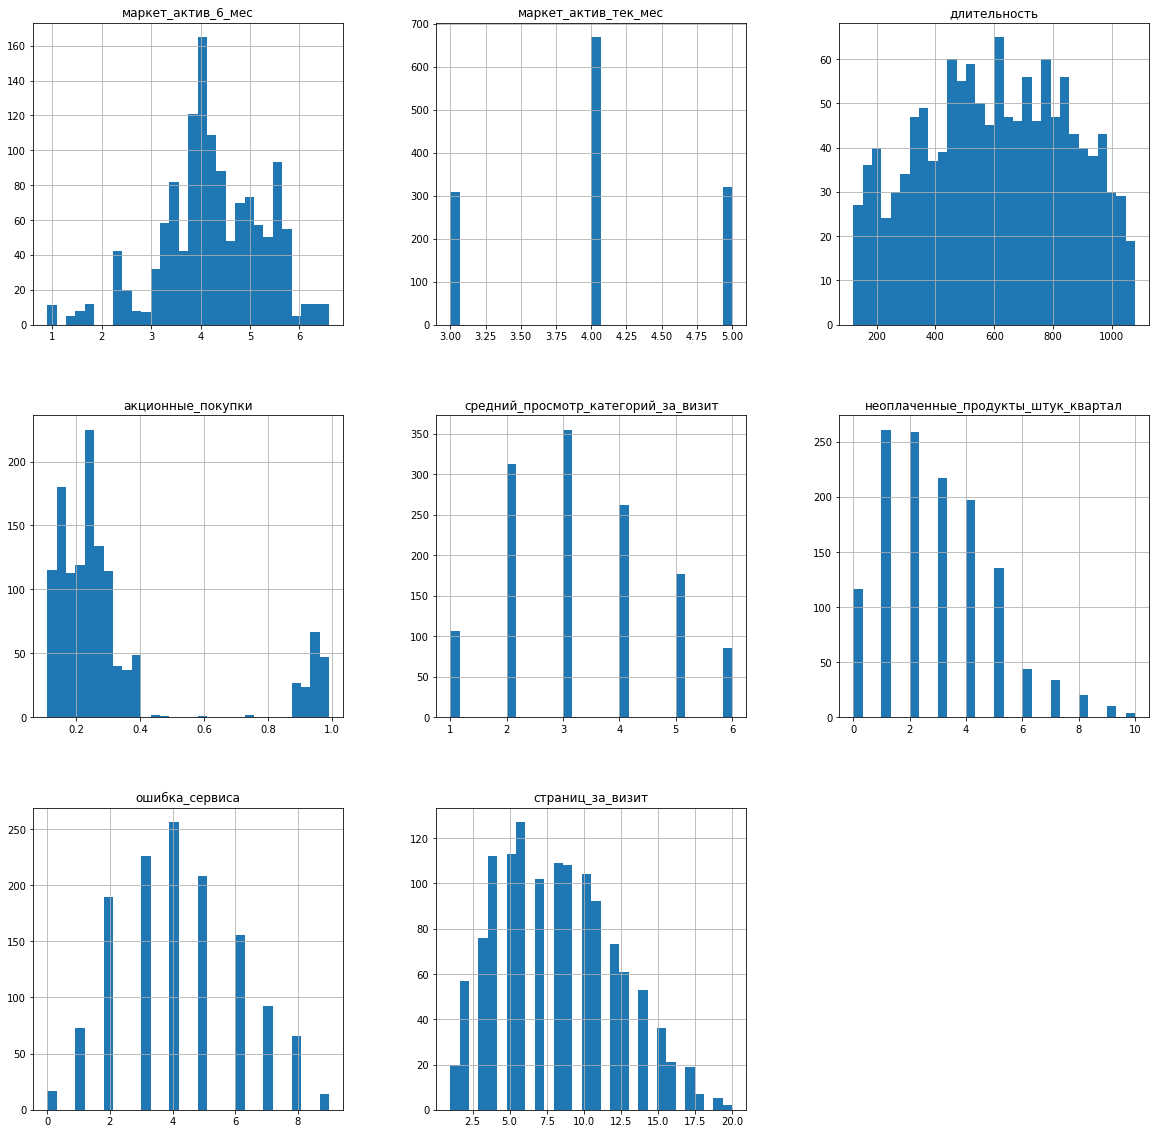

In [24]:
market_file.drop('id', axis=1).hist(figsize=(20, 20),bins=30);

Пока выбросов не наблюдается.

**Исследование категориальных показателей**

In [25]:
def pie_market(data):
    list_c = data.select_dtypes(include='object').columns.tolist()
    for index in list_c:
        str = index
        print ('\033[1m' +str.center(100))
        table = data.pivot_table(index=index, values='id', aggfunc='count')
        table.columns = ['Количество']
        display(table.sort_values('Количество',ascending=False))
        ax = table.plot(kind='pie', y='Количество', autopct='%1.1f%%', figsize=(4,4));
        ax.get_legend().remove()
        plt.ylabel('')
        plt.title('Рапределение покупателей по показателю "' + index + '"')

                                     покупательская_активность                                      


,Количество
покупательская_активность,
Прежний уровень,802
Снизилась,495


                                            тип_сервиса                                             


,Количество
тип_сервиса,
стандарт,922
премиум,375


                                         разрешить_сообщать                                         


,Количество
разрешить_сообщать,
да,959
нет,338


                                        популярная_категория                                        


,Количество
популярная_категория,
Товары для детей,329
Домашний текстиль,250
Косметика и аксессуары,223
Техника для красоты и здоровья,183
Мелкая бытовая техника и электроника,174
Кухонная посуда,138


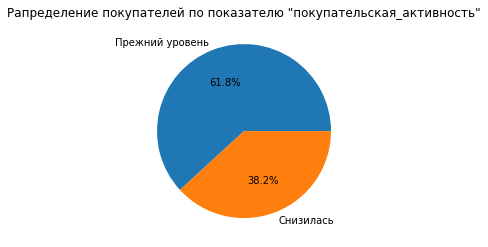

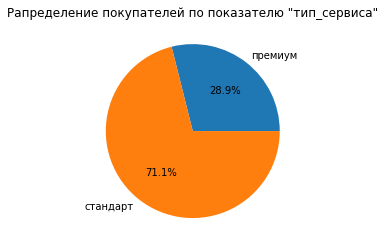

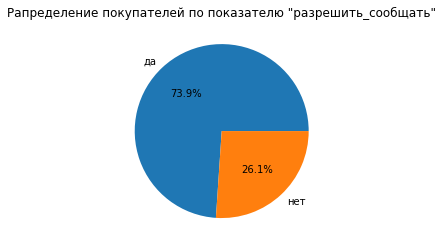

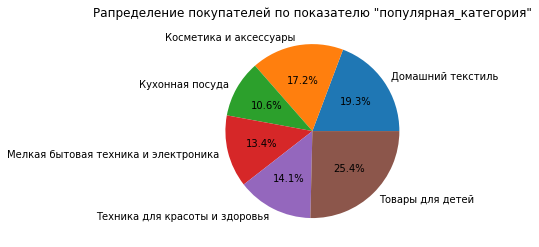

In [26]:
pie_market(market_file)

**По итогам исследования категориальных признаков датасета `market_file` выявлено, что:**

- у 38,3% покупателей снизилась покупательская активность, а у остальных осталась на прежнем уровне
- среди покупателей преобладают с типом сервиса 'стандарт' (71,1%)
- 74% покупателей согласны на дополнительные предложения о товаре
- 25,4% покупателей ориентированы на приобретение товаров для детей, 19,3% - на приобретение домашнего текстиля, 17,2% - на приобретение косметики и аксессуаров, 14,2% - на приоретение техники для красоты и здоровья, 13,4% - на приобретение мелкой бытовой техники и электроники, 10,6% - на приобретение кухонной посуды.

**Показатель 'маркет_ актив_ 6_ мес'**

In [27]:
def hist_plot(data,index,bins):
    plt.figure(figsize=(20, 5))
    plt.suptitle('Гистограмма и диаграмма размаха для показателя "' + index+'"', fontsize=20, y=1.05)
        
    
    plt.subplot(1, 2, 1)
    mean = np.mean(data[index])
    median = np.median(data[index])
    sns.histplot(data[index], bins=bins, kde=True, color='skyblue')
    plt.axvline(mean, color='r', linestyle='dashed', linewidth=1, label=f'Среднее: {mean:.2f}')
    plt.axvline(median, color='g', linestyle='dashed', linewidth=1, label=f'Медиана: {median:.2f}');
    plt.ylabel('Количество показателей')
    plt.title('Гистограмма по значению ' + index, fontsize=16)
    plt.legend()
    plt.xlabel(index);
    
    plt.subplot(1, 2, 2)
    ax = sns.boxplot(y=index, data=data)
    plt.title('Boxplot для показателя ' + index, fontsize=16)
    plt.axhline(y=mean, color='g', linestyle='--')
    plt.ylabel(index, fontsize=14);
    plt.show()

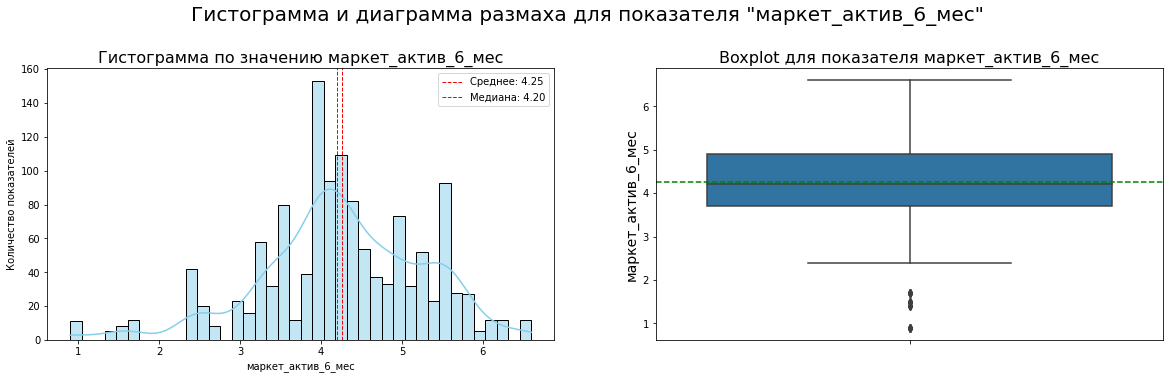

In [28]:
hist_plot(market_file,'маркет_актив_6_мес',40)

**Показатель 'маркет_актив_тек_мес'**

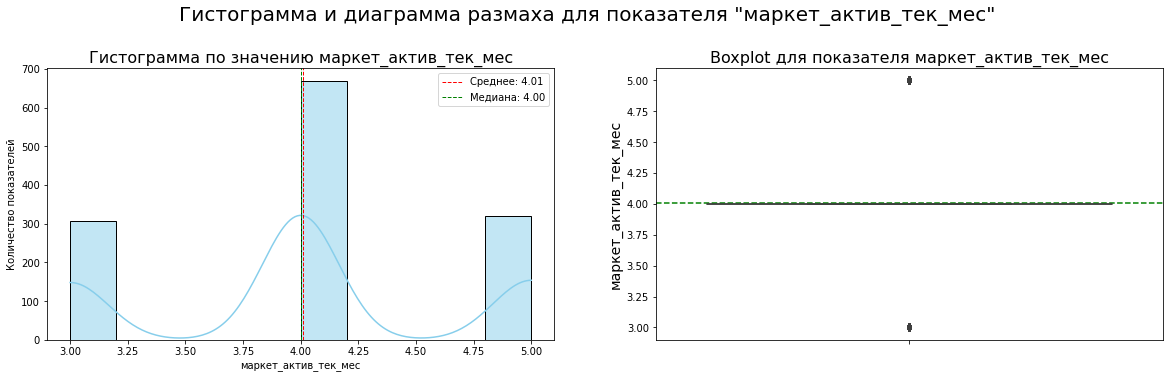

In [29]:
hist_plot(market_file,'маркет_актив_тек_мес',10)

**Показатель 'длительность'**

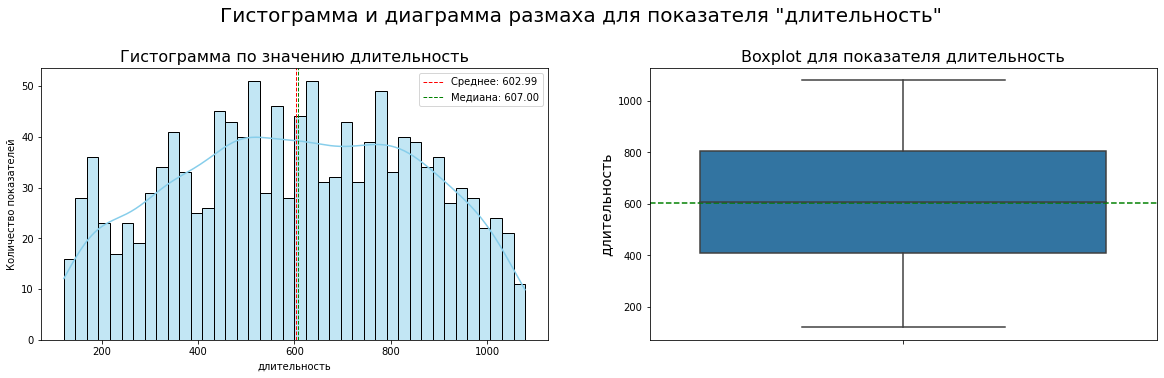

In [30]:
hist_plot(market_file,'длительность',40)

**Показатель 'акционные_покупки'**

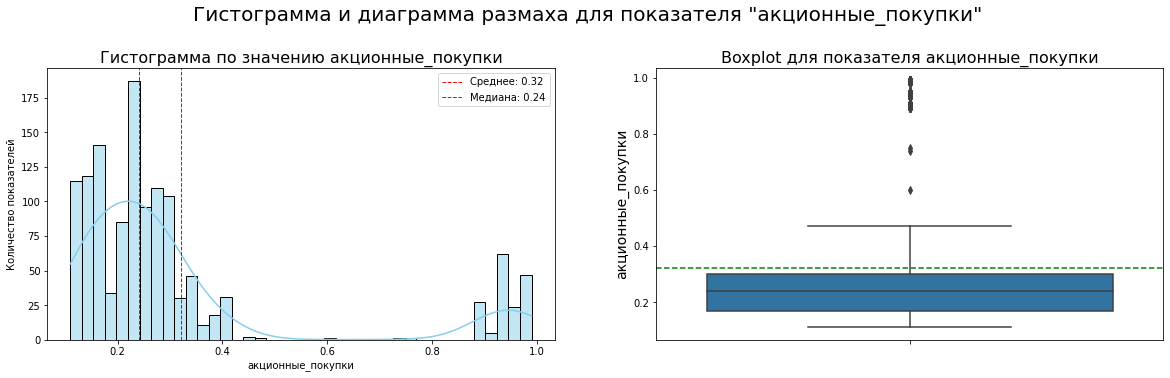

In [31]:
hist_plot(market_file,'акционные_покупки',40)

**Показатель 'средний_просмотр_категорий_за_визит'**

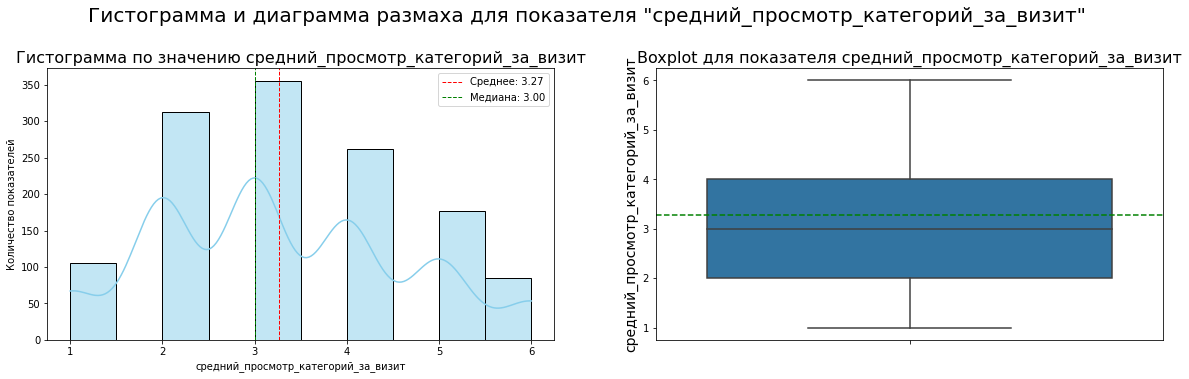

In [32]:
hist_plot(market_file,'средний_просмотр_категорий_за_визит',10)

**Показатель 'неоплаченные_продукты_штук_квартал'**

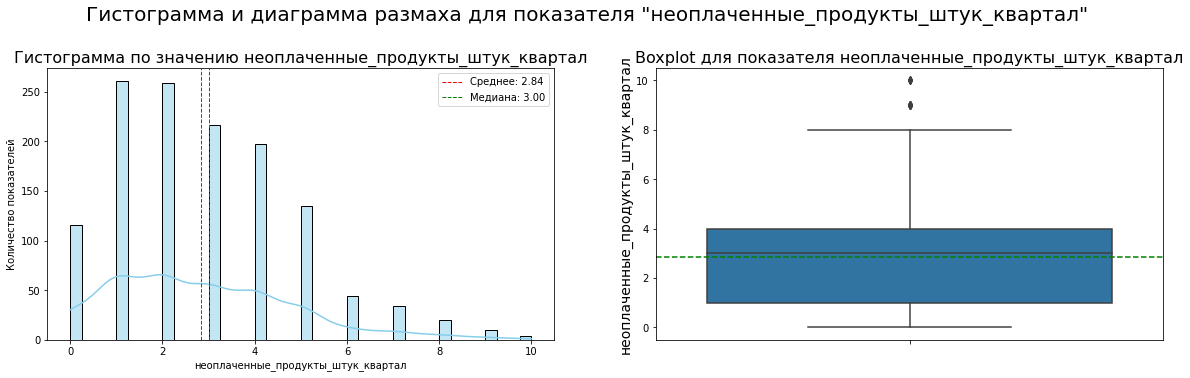

In [33]:
hist_plot(market_file,'неоплаченные_продукты_штук_квартал',40)

**Показатель 'ошибка_сервиса'**

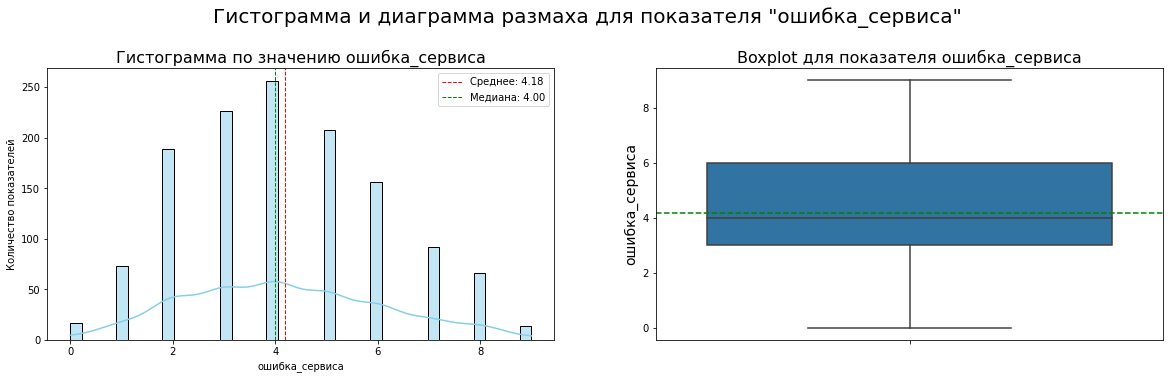

In [34]:
hist_plot(market_file,'ошибка_сервиса',40)

**Показатель 'страниц_за_визит'**

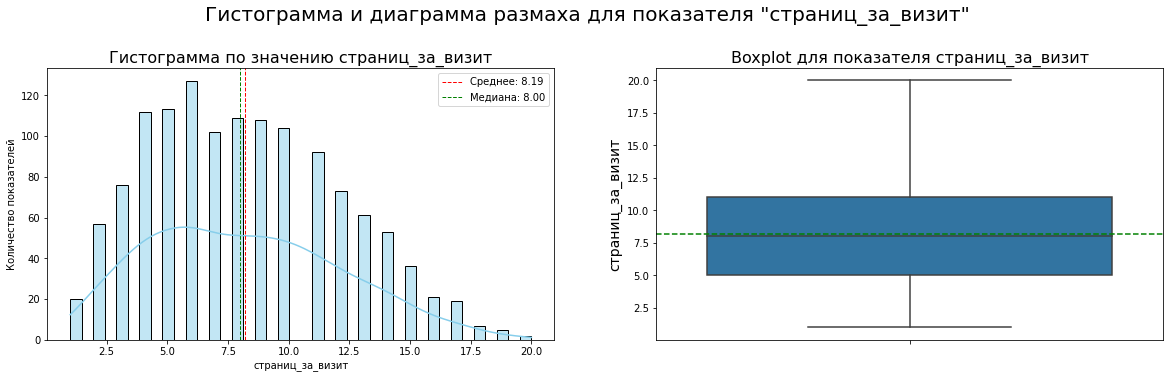

In [35]:
hist_plot(market_file,'страниц_за_визит',40)

### Исследовательский анализ данных для датасета 'market_money'

In [36]:
market_money.describe()

,id,выручка
count,3891.000000,3891.000000
mean,215998.986893,5033.718890
std,374.482249,1768.471286
min,215349.000000,2758.700000
25%,215675.000000,4592.000000
50%,215999.000000,4959.000000
75%,216323.000000,5363.200000
max,216647.000000,106862.200000


Присутствуют явные выбросы в выручке.

**Исследование категориальных показателей**

                                               период                                               


,Количество
период,
предыдущий_месяц,1297
препредыдущий_месяц,1297
текущий_месяц,1297


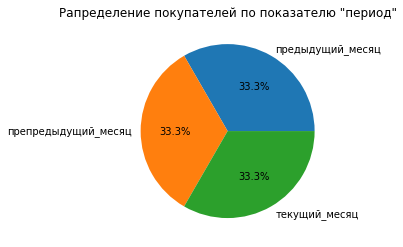

In [37]:
pie_market(market_money)

Все предсказуемо, как и писалось раньше. По каждому покупателю данные за каждый месяц в отдельной строке.

**Показатель 'выручка'**

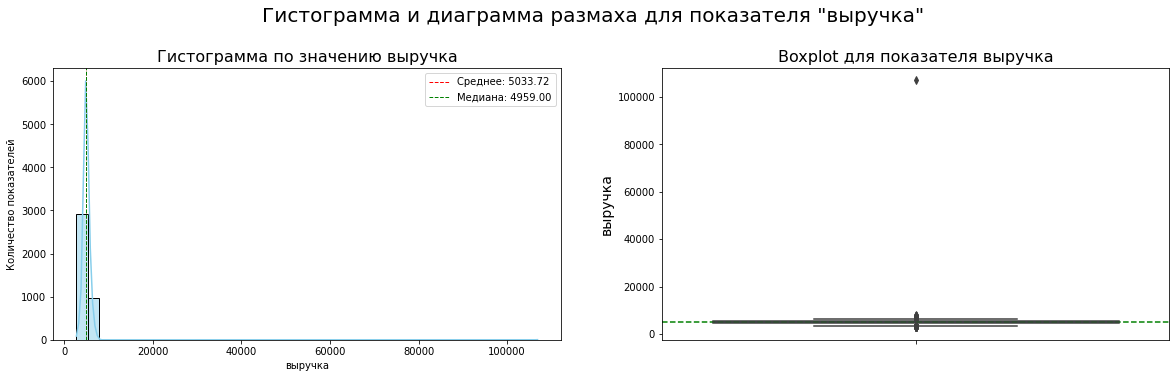

In [38]:
hist_plot(market_money,'выручка',40)

Проверим показатели выручки.

In [39]:
market_money.sort_values(by = 'выручка',ascending=False)

,id,период,выручка
98,215380,текущий_месяц,106862.2
435,215493,текущий_месяц,7799.4
262,215435,текущий_месяц,7605.3
1481,215841,текущий_месяц,7557.0
2388,216144,текущий_месяц,7547.8
...,...,...,...
392,215478,предыдущий_месяц,2960.0
2485,216176,текущий_месяц,2952.2
662,215568,предыдущий_месяц,2909.0
649,215564,предыдущий_месяц,2890.0


Один из покупателей сделал очень большую покупку на сайте. Или этот показатель является результатом технической ошибки. Но на модель это будет очень сильно влиять.

In [40]:
big_sales_id = market_money.query('выручка>7800')
display(big_sales_id)

,id,период,выручка
98,215380,текущий_месяц,106862.2


In [41]:
display(market_file.loc[market_file['id'].isin(big_sales_id['id'])])

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит
32,215380,Снизилась,премиум,нет,1.7,4,637,0.94,Техника для красоты и здоровья,3,2,4,7


Удалим из всех датасетов данные об этом покупателе.

In [42]:
for index in big_sales_id['id'].unique():
    market_money = market_money.drop(market_money[market_money['id'] == index].index)
    market_file = market_file.drop(market_file[market_file['id'] == index].index)
    market_time = market_time.drop(market_time[market_time['id'] == index].index)
    money = money.drop(money[money['id']==index].index)

Проверим процент общего удаления данных.

In [43]:
print ('Процент удаленных строк от минимального количества строк в датасетах: ',\
       "{:.1%}".format((market_money_nul['id'].nunique()+big_sales_id['id'].nunique())/1300))

Процент удаленных строк от минимального количества строк в датасетах:  0.3%


0.3% - это незначительное значение.

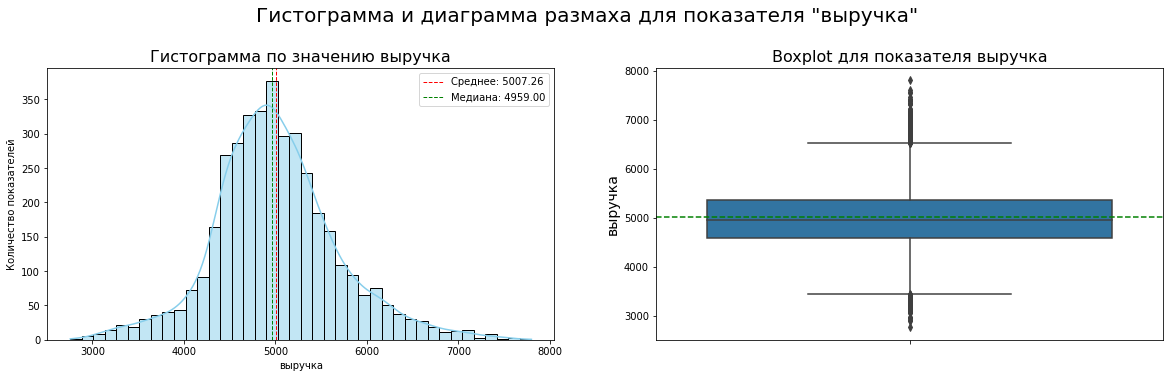

In [44]:
hist_plot(market_money,'выручка',40)

### Исследовательский анализ данных для датасета 'market_time'

In [45]:
market_time.describe()

,id,минут
count,2592.000000,2592.000000
mean,215999.464506,13.340664
std,374.255617,4.083469
min,215349.000000,4.000000
25%,215675.750000,10.000000
50%,215999.500000,13.000000
75%,216323.250000,16.000000
max,216647.000000,23.000000


**Исследование категориальных показателей**

                                               период                                               


,Количество
период,
предыдущий_месяц,1296
текущий_месяц,1296


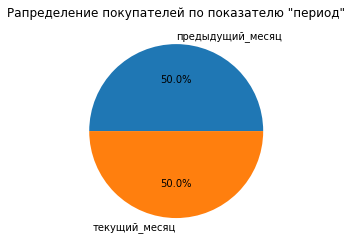

In [46]:
pie_market(market_time)

Здесь наблюдается таже картина, что и в случае с датасетом 'market_money'. Данные представлены по каждому покупателю дважды в отдельной строке по каждому месяцу.

**Показатель 'минут'**

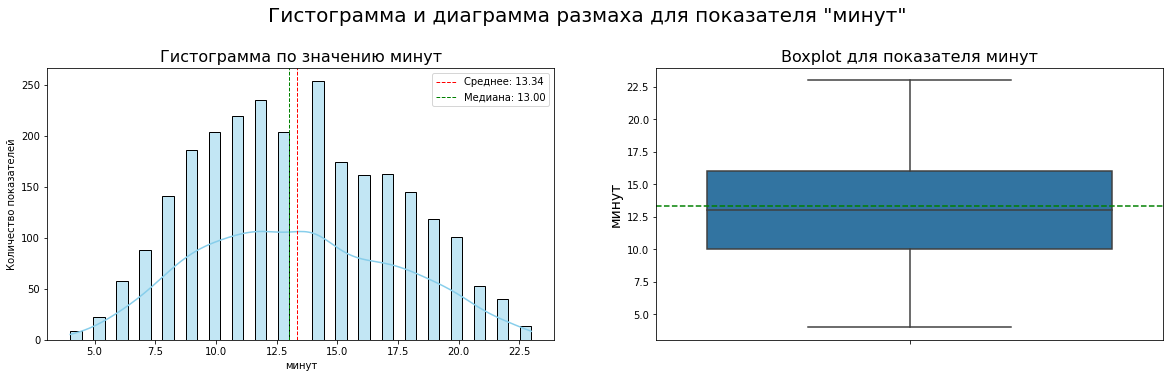

In [47]:
hist_plot(market_time,'минут',40)

### Исследовательский анализ данных для датасета 'money'

In [48]:
money.describe()

,id,прибыль
count,1296.000000,1296.000000
mean,215999.464506,3.997701
std,374.327860,1.011198
min,215349.000000,0.860000
25%,215675.750000,3.300000
50%,215999.500000,4.045000
75%,216323.250000,4.670000
max,216647.000000,7.430000


**Показатель 'прибыль'**

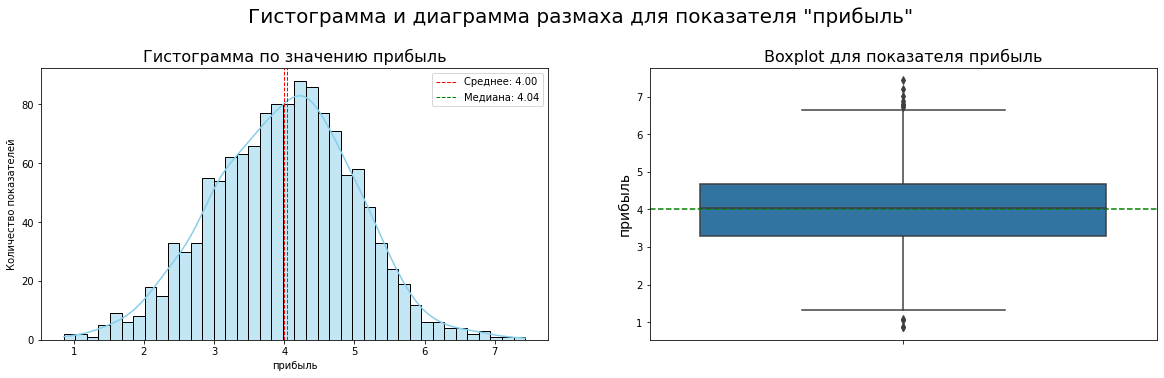

In [49]:
hist_plot(money,'прибыль',40)

**<div style="border:solid green 2px; padding: 20px">
Вывод: На 2 шаге были исследованы данные четырех датафреймов. Были удалены покупатели с покупательской активностью ниже, чем остальные покупатели. Был удален выброс в датасете 'market_money'.**

## Шаг. Объединение таблиц 'market_file','market_money' и 'market_time'

Необходимо рассортировать датасеты 'market_money' и 'market_time'.

In [50]:
market_money.head(10)

,id,период,выручка
3,215349,препредыдущий_месяц,4472.0
4,215349,текущий_месяц,4971.6
5,215349,предыдущий_месяц,5216.0
6,215350,препредыдущий_месяц,4826.0
7,215350,текущий_месяц,5058.4
8,215350,предыдущий_месяц,5457.5
9,215351,текущий_месяц,6610.4
10,215351,предыдущий_месяц,6158.0
11,215351,препредыдущий_месяц,4793.0
12,215352,предыдущий_месяц,5807.5


In [51]:
market_money_new = market_money.pivot(index='id', columns='период', values='выручка').reset_index()
market_money_new.columns = ['id','выручка_за_пред_месяц','выручка_за_препред_месяц','выручка_за_текущ_месяц']
market_money_new.head(10)

,id,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц
0,215349,5216.0,4472.0,4971.6
1,215350,5457.5,4826.0,5058.4
2,215351,6158.0,4793.0,6610.4
3,215352,5807.5,4594.0,5872.5
4,215353,4738.5,5124.0,5388.5
5,215354,5685.0,4503.0,5869.6
6,215355,3263.0,4749.0,3772.6
7,215356,4146.5,4433.0,4566.4
8,215358,3488.0,4727.0,4209.5
9,215360,5304.5,5555.0,5834.9


Проведем проверку.

In [52]:
list_column = ['выручка_за_препред_месяц','выручка_за_текущ_месяц','выручка_за_пред_месяц']
for i in range(len(market_money['период'].unique())):
    print('Сумма выручки в датасете "market_money" по показателю "'+market_money['период'].unique()[i]+'":',\
          market_money.loc[(market_money['период']==market_money['период'].unique()[i]),'выручка'].sum())
    print('Cумма выручки в датасете "market_money_new" по столбцу "'+list_column[i]+'":',\
          market_money_new[list_column[i]].sum())

Сумма выручки в датасете "market_money" по показателю "препредыдущий_месяц": 6267718.0
Cумма выручки в датасете "market_money_new" по столбцу "выручка_за_препред_месяц": 6267718.0
Сумма выручки в датасете "market_money" по показателю "текущий_месяц": 6788572.5
Cумма выручки в датасете "market_money_new" по столбцу "выручка_за_текущ_месяц": 6788572.5
Сумма выручки в датасете "market_money" по показателю "предыдущий_месяц": 6411919.5
Cумма выручки в датасете "market_money_new" по столбцу "выручка_за_пред_месяц": 6411919.5


In [53]:
print('Количество строк в датасете "market_money_new":',market_money_new.shape[0])
print('Количество строк в датасете "market_file":',market_file.shape[0])

Количество строк в датасете "market_money_new": 1296
Количество строк в датасете "market_file": 1296


In [54]:
market_time.head(10)

,id,период,минут
2,215349,текущий_месяц,10
3,215349,предыдущий_месяц,12
4,215350,текущий_месяц,13
5,215350,предыдущий_месяц,8
6,215351,текущий_месяц,13
7,215351,предыдущий_месяц,11
8,215352,текущий_месяц,11
9,215352,предыдущий_месяц,8
10,215353,предыдущий_месяц,10
11,215353,текущий_месяц,10


In [55]:
market_time_new = market_time.pivot(index='id', columns='период', values='минут').reset_index()
market_time_new.columns = ['id','минут_за_пред_месяц','минут_за_текущ_месяц']
market_time_new.head(10)

,id,минут_за_пред_месяц,минут_за_текущ_месяц
0,215349,12,10
1,215350,8,13
2,215351,11,13
3,215352,8,11
4,215353,10,10
5,215354,11,12
6,215355,12,10
7,215356,6,7
8,215358,14,10
9,215360,9,6


Проведем проверку.

In [56]:
list_time = ['минут_за_текущ_месяц','минут_за_пред_месяц']
for i in range(len(market_time['период'].unique())):
    print('Сумма минут в датасете "market_time" по показателю "'+market_time['период'].unique()[i]+'":',\
          market_time.loc[(market_time['период']==market_time['период'].unique()[i]),'минут'].sum())
    print('Cумма выручки в датасете "market_time_new" по столбцу "'+list_time[i]+'":',\
          market_time_new[list_time[i]].sum())

Сумма минут в датасете "market_time" по показателю "текущий_месяц": 17121
Cумма выручки в датасете "market_time_new" по столбцу "минут_за_текущ_месяц": 17121
Сумма минут в датасете "market_time" по показателю "предыдущий_месяц": 17458
Cумма выручки в датасете "market_time_new" по столбцу "минут_за_пред_месяц": 17458


In [57]:
print('Количество строк в датасете "market_time_new":',market_time_new.shape[0])
print('Количество строк в датасете "market_file":',market_file.shape[0])

Количество строк в датасете "market_time_new": 1296
Количество строк в датасете "market_file": 1296


Объединим таблицы по признаку 'id'.

In [58]:
market = market_file.merge(market_money_new, on = 'id')
market= market.merge(market_time_new,on = 'id')
display(market.head(10))

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц,минут_за_пред_месяц,минут_за_текущ_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10
5,215354,Снизилась,стандарт,да,5.1,3,431,0.23,Косметика и аксессуары,2,3,7,2,5685.0,4503.0,5869.6,11,12
6,215355,Снизилась,стандарт,нет,4.7,4,284,0.17,Товары для детей,5,1,6,4,3263.0,4749.0,3772.6,12,10
7,215356,Снизилась,стандарт,да,4.2,4,192,0.14,Косметика и аксессуары,2,2,1,3,4146.5,4433.0,4566.4,6,7
8,215358,Снизилась,стандарт,да,4.7,4,450,0.13,Домашний текстиль,4,2,6,4,3488.0,4727.0,4209.5,14,10
9,215360,Снизилась,премиум,да,3.9,3,623,0.35,Кухонная посуда,3,1,4,7,5304.5,5555.0,5834.9,9,6


In [59]:
print('Количество дубликатов: ',market.duplicated().sum())

Количество дубликатов:  0


Проанализируем все показатели по двум интересующим целевым показателям (снизилась/прежний уровень)

Разделим для удобства датасет 'market' по покупательской активности.

In [60]:
market_sniz = market.query('покупательская_активность=="Снизилась"')
market_pu = market.query('покупательская_активность=="Прежний уровень"')

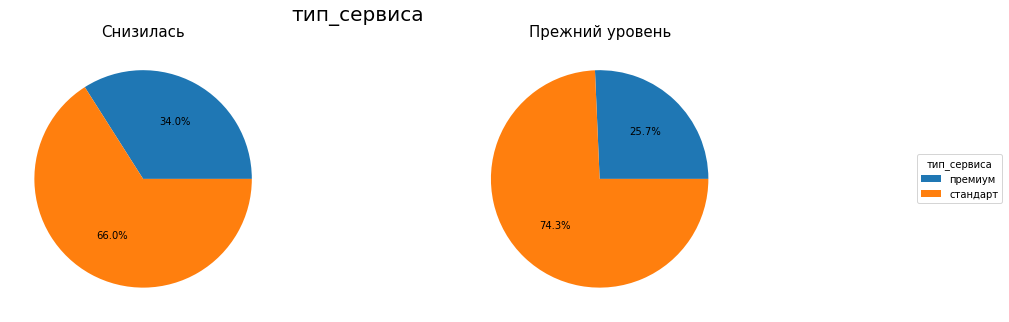

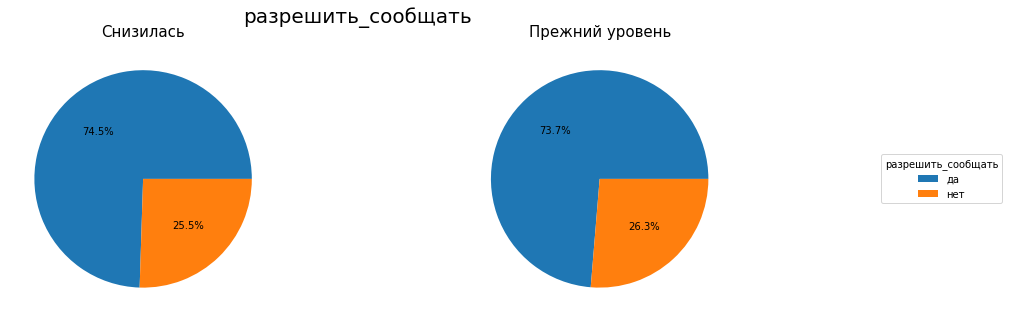

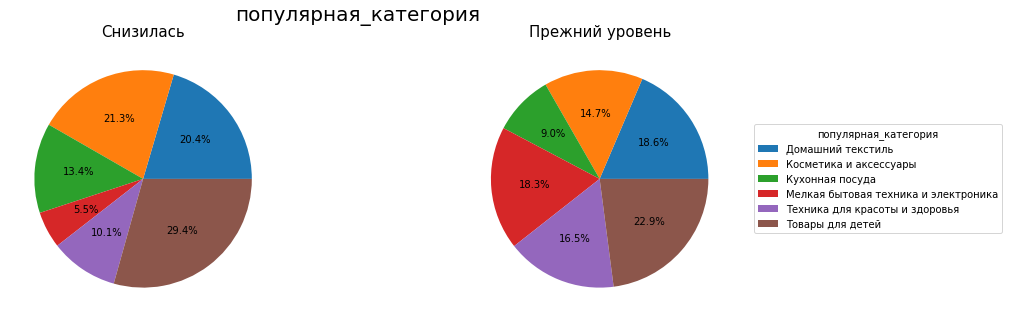

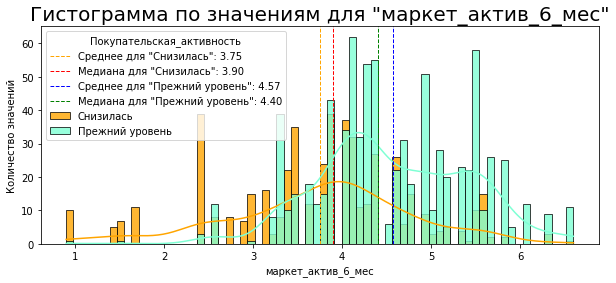

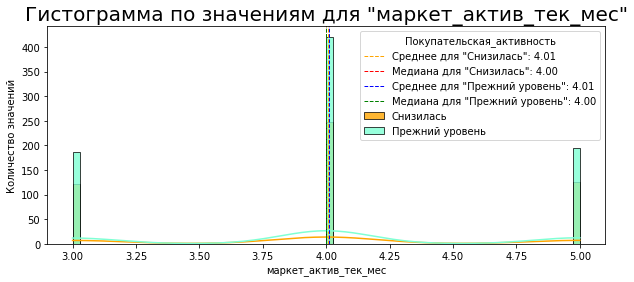

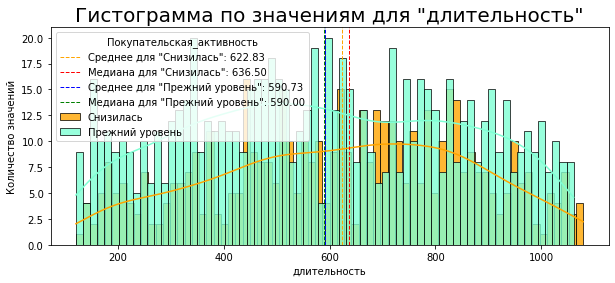

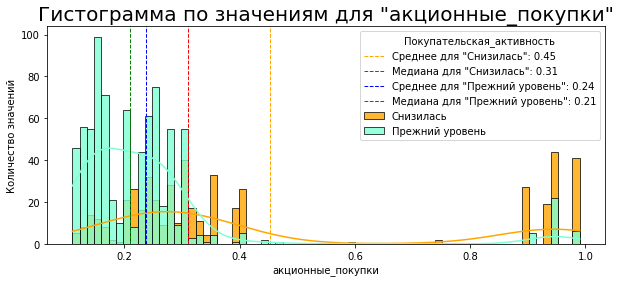

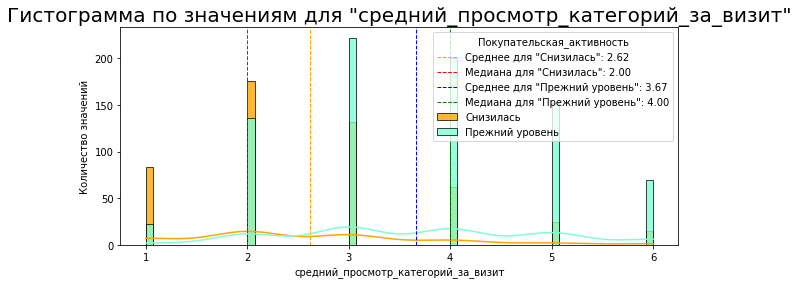

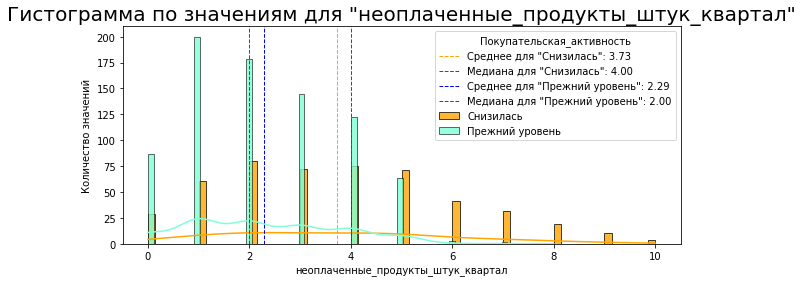

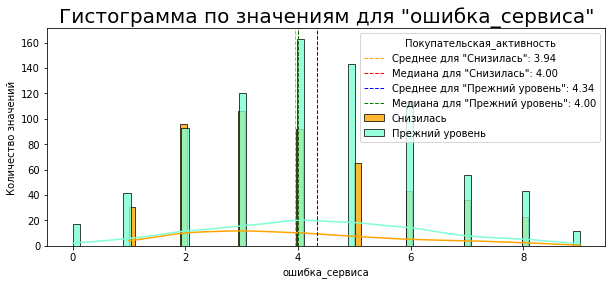

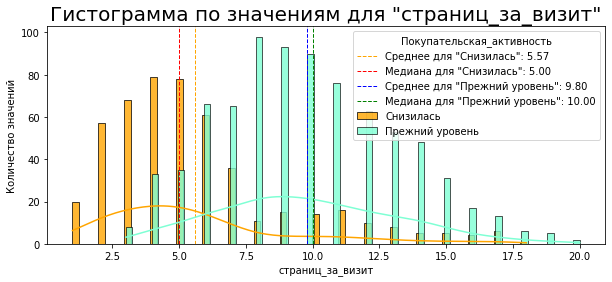

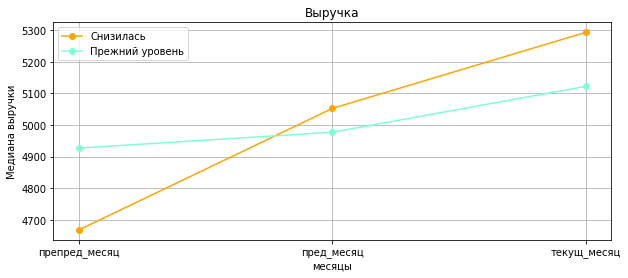

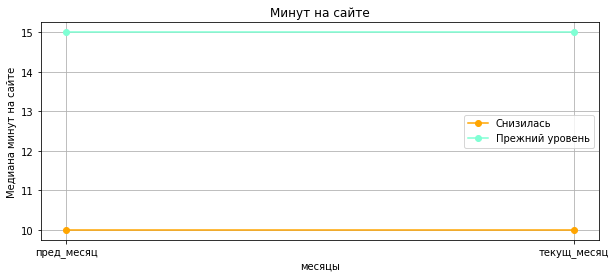

In [61]:
list_c = market.drop('покупательская_активность', axis=1).select_dtypes(include='object').columns.tolist()
for name in list_c:
    table_sniz = market_sniz.pivot_table(index=name, values='id', aggfunc='count').reset_index()
    table_pu = market_pu.pivot_table(index=name, values='id', aggfunc='count').reset_index()

    fig, axs = plt.subplots(1, 2, figsize=(15, 5))      
    plt.suptitle (name, fontsize=20)

    plt.subplot(1, 2, 1)
    plt.title('Снизилась', fontsize=15)
    plt.pie(table_sniz['id'].unique(), autopct='%1.1f%%',radius = 1)
    
    
    plt.subplot(1, 2, 2)
    plt.title('Прежний уровень', fontsize=15)
    plt.pie(table_pu['id'].unique(), autopct='%1.1f%%',radius = 1)
    plt.legend(title=name, loc="center right", bbox_to_anchor = (1.5,0,0.5,1),labels = table_pu[name].unique())
    
list_num = market.drop(['id',\
                       'выручка_за_пред_месяц',\
                       'выручка_за_препред_месяц',\
                       'выручка_за_текущ_месяц',\
                       'минут_за_пред_месяц',\
                       'минут_за_текущ_месяц'], axis=1).select_dtypes(include=['float64','int64']).columns.tolist()
for name in list_num:
    mean_sniz = np.mean(market_sniz[name])
    median_sniz = np.median(market_sniz[name])
    mean_pu = np.mean(market_pu[name])
    median_pu = np.median(market_pu[name])
    plt.figure(figsize=(10, 4))
    sns.histplot(market_sniz[name], bins=70, color='orange', alpha=0.8, label='Снизилась', kde=True)
    plt.axvline(mean_sniz, color='orange', linestyle='dashed', linewidth=1, label=f'Среднее для "Снизилась": {mean_sniz:.2f}')
    plt.axvline(median_sniz, color='red', linestyle='dashed', linewidth=1, label=f'Медиана для "Снизилась": {median_sniz:.2f}');
    sns.histplot(market_pu[name], bins=70, color='aquamarine', alpha=0.8, label='Прежний уровень', kde=True)
    plt.axvline(mean_pu, color='blue', linestyle='dashed', linewidth=1, label=f'Среднее для "Прежний уровень": {mean_pu:.2f}')
    plt.axvline(median_pu, color='green', linestyle='dashed', linewidth=1, label=f'Медиана для "Прежний уровень": {median_pu:.2f}');
    plt.legend(title='Покупательская_активность')
    plt.xlabel(name)
    plt.ylabel('Количество значений')
    plt.title('Гистограмма по значениям для "'+name+'"', fontsize=20);
    
data_sniz = [['препред_месяц', market_sniz['выручка_за_препред_месяц'].median()],\
        ['пред_месяц', market_sniz['выручка_за_пред_месяц'].median()],\
        ['текущ_месяц', market_sniz['выручка_за_текущ_месяц'].median()]]
columns = ['месяц','выручка']
market_sniz_sales = pd.DataFrame(data=data_sniz,columns = columns)
data_pu = [['препред_месяц', market_pu['выручка_за_препред_месяц'].median()],\
        ['пред_месяц', market_pu['выручка_за_пред_месяц'].median()],\
        ['текущ_месяц', market_pu['выручка_за_текущ_месяц'].median()]]
market_pu_sales = pd.DataFrame(data=data_pu,columns = columns)
plt.figure(figsize=(10,4))
plt.plot(market_sniz_sales['месяц'],market_sniz_sales['выручка'], color='orange', marker='o')
plt.plot(market_pu_sales['месяц'],market_pu_sales['выручка'],color='aquamarine',marker='o')
plt.title('Выручка')
plt.ylabel('Медиана выручки')
plt.xlabel('месяцы')
plt.grid(True)
plt.legend(['Снизилась', 'Прежний уровень']);

data_sniz = [['пред_месяц', market_sniz['минут_за_пред_месяц'].median()],\
        ['текущ_месяц', market_sniz['минут_за_текущ_месяц'].median()]]
columns = ['месяц','минут_на_сайте']
market_sniz_time = pd.DataFrame(data=data_sniz,columns = columns)
data_pu = [['пред_месяц', market_pu['минут_за_пред_месяц'].median()],\
        ['текущ_месяц', market_pu['минут_за_текущ_месяц'].median()]]
market_pu_time = pd.DataFrame(data=data_pu,columns = columns)
plt.figure(figsize=(10,4))
plt.plot(market_sniz_time['месяц'],market_sniz_time['минут_на_сайте'], color='orange', marker='o')
plt.plot(market_pu_time['месяц'],market_pu_time['минут_на_сайте'],color='aquamarine',marker='o')
plt.title('Минут на сайте')
plt.ylabel('Медиана минут на сайте')
plt.xlabel('месяцы')
plt.grid(True)
plt.legend(['Снизилась', 'Прежний уровень']);


<div style="border:solid green 2px; padding: 20px">
Вывод: На 3 шаге были объединены данные трех датафреймов. Также были сделаны выводы по каждой группе покупательской активности:
    
- ‘тип_сервиса’: у покупателей со снизившейся покупательской активностью преобладает тип сервиса ‘стандарт’ (66%) также, как и у покупателей с прежним уровнем покупательской активности
    
- ‘разрешить_сообщать’: в обеих группах покупательской активности преобладают покупатели с разрешением на дополнительные предложения о товаре. Показатели практически равны (74,5% покупателей в группе со снизившейся активностью, 73,7% - в группе с прежним уровнем активности)
    
- ‘маркет_ актив_ 6_ мес’: в группе со снизившейся покупательской активностью среднее и медианное значение коммуникаций несколько ниже (3,75 и 3,90 соответственно), чем те же значения для покупателей с прежним уровнем активности (4,57 и 4,40 соответственно). Возможно, стоит увеличить объем коммуникаций для группы со снизившейся покупательской активностью.
    
- ‘маркет_актив_тек_мес’: объем коммуникаций в текущем месяце у групп покупательской активности совпадает по среднему и медианному значению (4,01 и 4,00 соответственно).
    
- ‘длительность’: судя по значениям среднего и медианы, снизилась активность у покупателей, которые дольше присутствуют на сайте. Для покупателей со снизившейся активностью средний и медианный показатели составили 622,33 и 636,50 дней с момента регистрации на сайте. У покупателей с прежним уровнем активности эти показатели составили 590,73 и 590,00 дней соответственно для среднего и медианного значений.
    
- ‘акционные_покупки’: у покупателей со снизившейся активностью согласно данным и среднем и медианном показателях доля акционных покупок была больше (0,45 и 0,31 соответственно). Покупатели с прежним уровнем активности меньше интересовались акционными покупками (среднее значение доли акционных покупок – 0,24, медианное – 0,21).
    
- ‘популярная_категория’: в группе покупателей со снизившейся покупательской активностью преобладает интерес к товарам для детей (29,4%), косметике и аксессуарам (21,3%) и домашнему текстилю (20,4%). В группе покупателей с прежним уровнем активности преобладает интерес к товарам для детей (22,9%), домашнему текстилю (18,6%) и мелкой бытовой технике и электронике (18,3%).
    
- ‘средний_просмотр_категорий_за_визит’: покупатели со снизившейся активностью просматривали меньшее количество категорий товаров за последний месяц. Среднее значение составило 2,62 категории, медианное – 2,00). В то же время покупатели с прежней покупательской активностью в среднем посмотрели 3,67 категории, а медианное значение составило 4 категории.
    
- ‘неоплаченные_продукты_штук_квартал’: у покупателей со снизившейся активностью количество неоплаченных товаров в корзине за последние 3 месяца преобладало по сравнению с покупателями с прежней активностью. Для них среднее значение количества таких товаров составило 3,73, а медианное – 4,00. В это же время у покупателей с прежним уровнем активности среднее значение неоплаченных товаров составило 2,29, а медианное – 2,00.
    
- ‘ошибка_сервиса’: по количеству сбоев покупатели обеих групп активности по медианному значению совпадают (4 сбоя, которые коснулись покупателя за время посещения сайта). Среднее же значение больше у группы с прежней активностью (4,34 сбоя). При этом среднее значение у группы со снизившейся активностью составляет 3,94 сбоя.
    
- ‘страниц_за_визит’: у покупателей со снизившейся активностью наблюдается меньший объем просмотра страниц за один визит за последние 3 месяца (среднее – 5,57, медиана – 5,00). При этом у покупателей с прежним уровнем активности средний показатель составляет 9,80 страниц, а медиана – 10,00.
    
- ‘выручка’: медианная выручка на одного покупателя в группе со снизившейся активностью за последние 2 месяца преобладала над медианной выручкой группы с прежней активностью.
    
- ‘минут на сайте’: медианное значение времени, проведенного на сайте, для группы со снизившейся активностью меньше, чем у группы с прежне активностью (10 против 15).

**Предварительное предположение: возможно, что покупатели со снизившейся активностью более ориентированы на акции. Отсюда меньший интерес к другим разделам, меньшее время на сайте. А товары закидывают в корзину в ожидании акции на них. Для таких клиентов лучше давать новые акции и рассылать о них сообщения**


## Шаг. Корреляционный анализ

Ниже представлена таблица коэффициентов корреляции (шкала Чеддока):

| Значение       | Интерпретация  |
|:--------------:|:--------------:|
| от 0 до 0,3    | очень слабая   |
| от 0,3 до 0,5  | слабая         |
| от 0, 5 до 0,7 | средняя        |
| от 0,7 до 0,9 | высокая        |
| от 0,9 до 1    | очень высокая  |

Используем библиотеку phik для подсчёта корреляции между признаками разных типов данных.

In [62]:
market.head()

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц,минут_за_пред_месяц,минут_за_текущ_месяц
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10


In [63]:
# создаём список с наименованиями непрерывных признаков
interval_cols = market.select_dtypes(include=['int64','float64']).columns.tolist()

# считаем корреляции на тренировочной выборке
phik_overview = phik_matrix(market.drop('id', axis=1), interval_cols=interval_cols)
display(phik_overview.round(2))

,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц,минут_за_пред_месяц,минут_за_текущ_месяц
покупательская_активность,1.00,0.13,0.00,0.54,0.00,0.10,0.51,0.30,0.54,0.51,0.22,0.75,0.22,0.50,0.20,0.69,0.58
тип_сервиса,0.13,1.00,0.29,0.09,0.05,0.40,0.03,0.07,0.19,0.12,0.08,0.10,0.00,0.07,0.12,0.13,0.00
разрешить_сообщать,0.00,0.29,1.00,0.00,0.05,0.25,0.01,0.07,0.07,0.20,0.02,0.04,0.08,0.00,0.06,0.04,0.00
маркет_актив_6_мес,0.54,0.09,0.00,1.00,0.08,0.00,0.28,0.15,0.21,0.29,0.14,0.40,0.16,0.32,0.04,0.36,0.33
маркет_актив_тек_мес,0.00,0.05,0.05,0.08,1.00,0.17,0.00,0.14,0.25,0.14,0.12,0.00,0.05,0.00,0.00,0.11,0.06
длительность,0.10,0.40,0.25,0.00,0.17,1.00,0.00,0.00,0.19,0.19,0.18,0.12,0.13,0.11,0.15,0.03,0.10
акционные_покупки,0.51,0.03,0.01,0.28,0.00,0.00,1.00,0.12,0.20,0.24,0.00,0.31,0.06,0.23,0.07,0.26,0.25
популярная_категория,0.30,0.07,0.07,0.15,0.14,0.00,0.12,1.00,0.23,0.25,0.00,0.16,0.25,0.04,0.24,0.20,0.09
средний_просмотр_категорий_за_визит,0.54,0.19,0.07,0.21,0.25,0.19,0.20,0.23,1.00,0.33,0.07,0.26,0.10,0.18,0.09,0.16,0.18
неоплаченные_продукты_штук_квартал,0.51,0.12,0.20,0.29,0.14,0.19,0.24,0.25,0.33,1.00,0.03,0.36,0.25,0.26,0.23,0.26,0.23


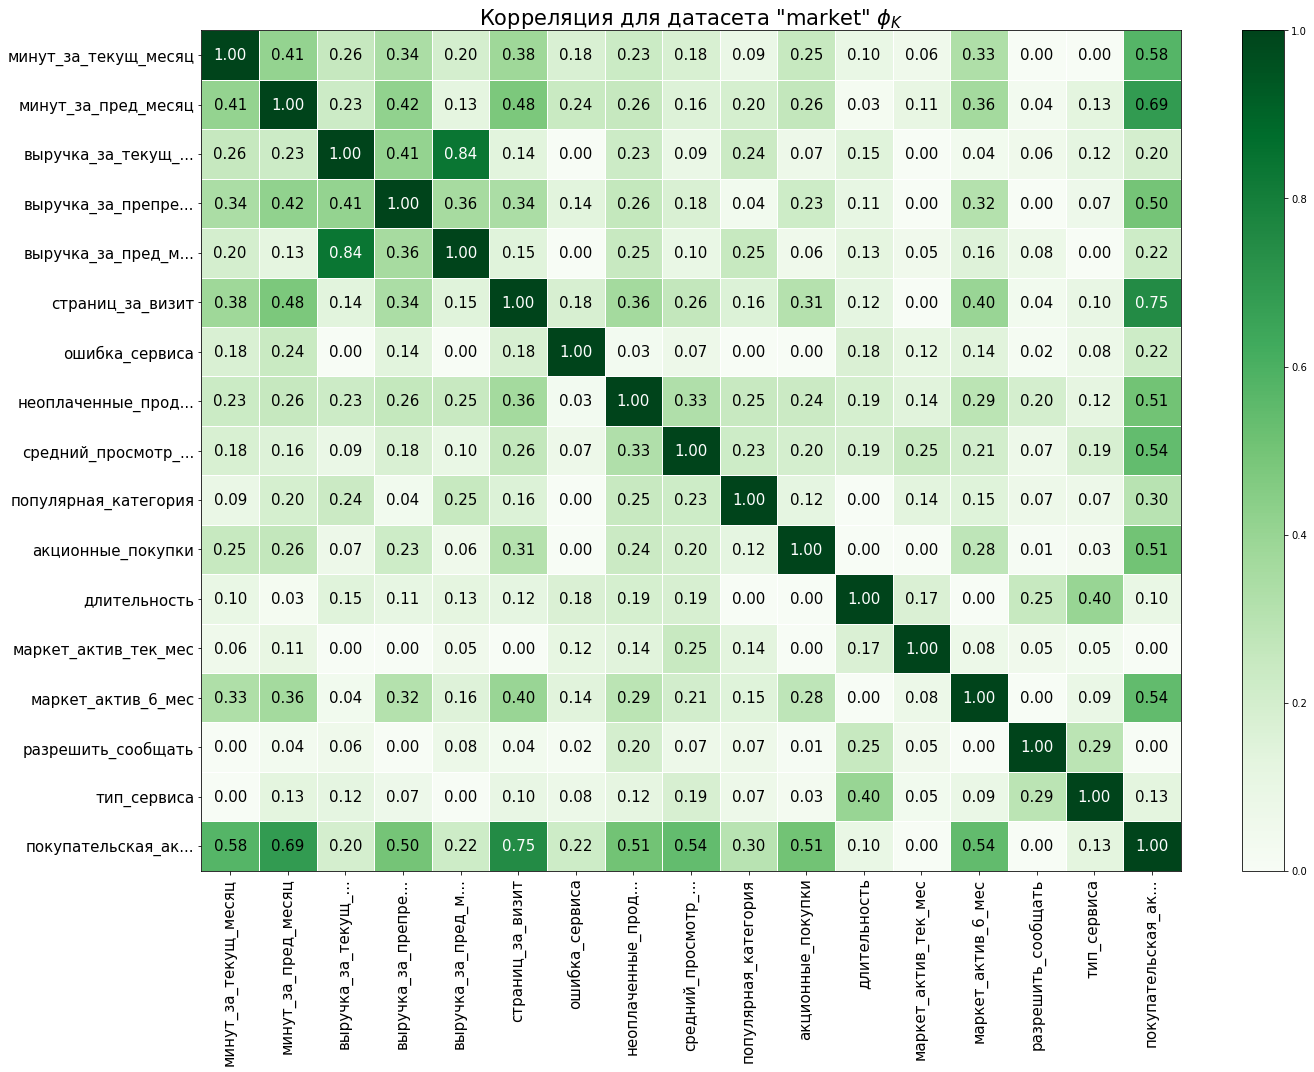

In [64]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция для датасета "market" $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Проанализируем показатели матрицы для каждой группы покупательской активности.

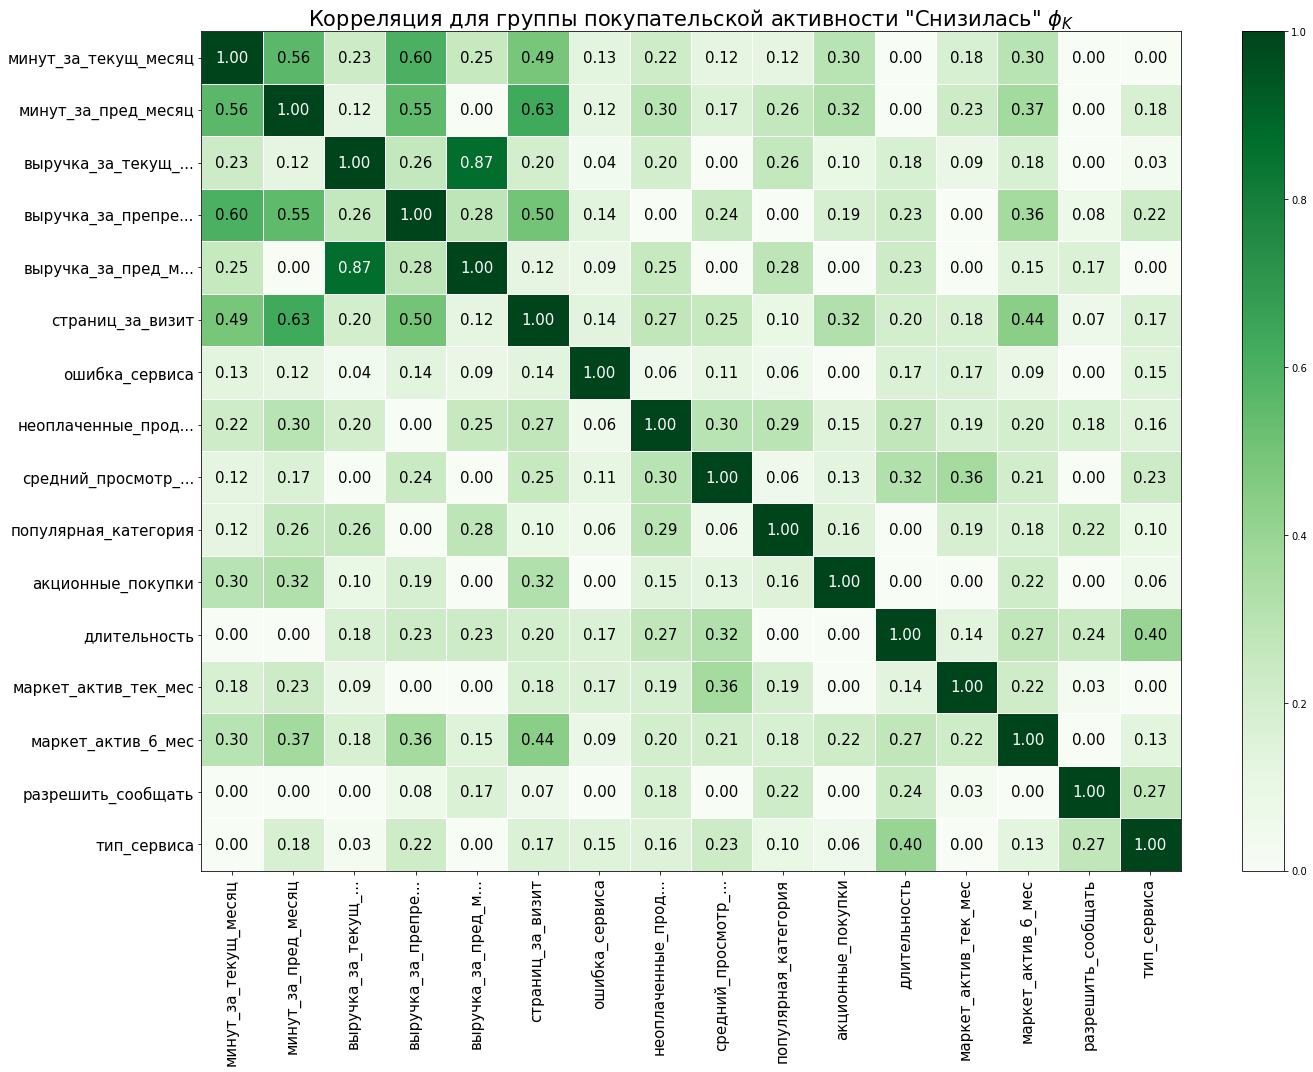

In [65]:
phik_overview = phik_matrix(market_sniz.drop('id', axis=1), interval_cols=interval_cols).round(2)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция для группы покупательской активности "Снизилась" $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

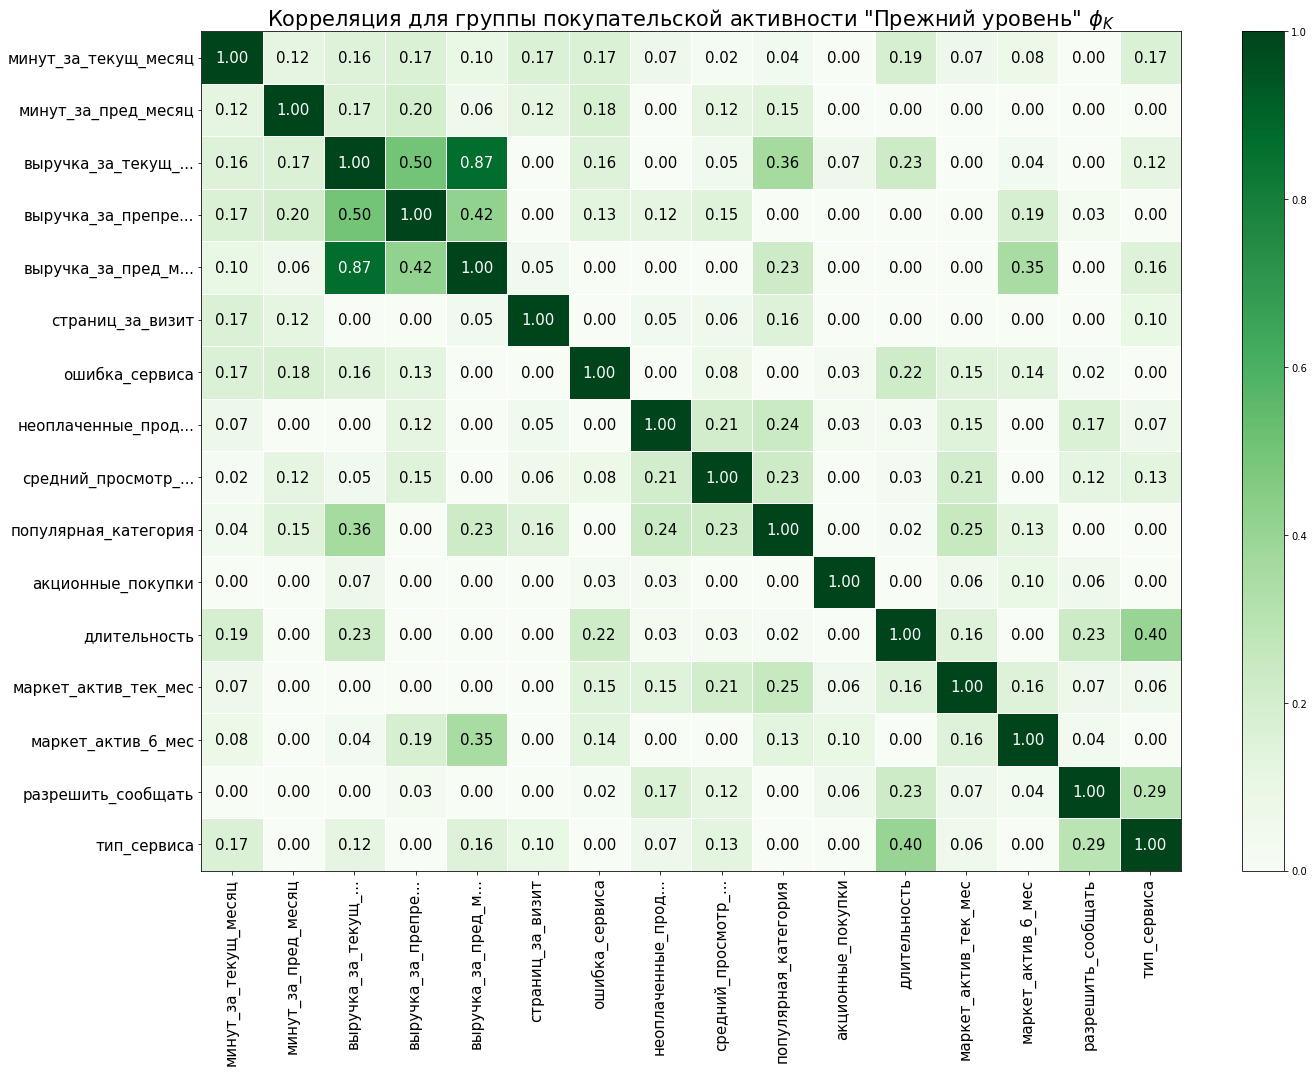

In [66]:
phik_overview = phik_matrix(market_pu.drop('id', axis=1), interval_cols=interval_cols).round(2)

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'Корреляция для группы покупательской активности "Прежний уровень" $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 4 было выявлены различные уровни корреляции (в том числе, достаточно высоких для ряда признаков:
    
1.	Для общего датасета ‘market’:
    
- **высокая корреляция** для показателей выручки за предыдущий и текущий месяцы (коэффициент 0,84)
- **высокая корреляция** для показателей покупательской активности и средним количеством страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца (коэффициент 0,75)
- средняя корреляция для показателей покупательской активности и количеством минут, проведенных на сайте в текущем месяце (коэффициент 0,58)
- средняя корреляция для показателей покупательской активности и количеством минут, проведенных на сайте в предыдущем месяце (коэффициент 0,69)
- средняя корреляция для показателей покупательской активности и выручкой за препредыдущий месяц (коэффициент 0,50)
- средняя корреляция для показателей покупательской активности и общим числом неоплаченных товаров в корзине за последние 3 месяца (коэффициент 0,51)
- средняя корреляция для показателей покупательской активности и количеством просмотренных категорий (коэффициент 0,54)
- средняя корреляция для показателей покупательской активности и долей акционных покупок от общего объема покупок (коэффициент 0,51)
- средняя корреляция для показателей покупательской активности и среднемесячным количеством коммуникаций за последние 6 месяцев (коэффициент 0,54)
2.	Для общего датасета ‘market_sniz’ (**для покупателей со снизившейся покупательской активностью**):
- **высокая корреляция** для показателей выручки за предыдущий и текущий месяцы (коэффициент 0,87)
- средняя корреляция для показателей времени, проведенного на сайте за текущий и предыдущий месяцы (0,56)
- средняя корреляция для показателей выручки за препредыдущий месяц и времени на сайте за текущий месяц (0,60)
- средняя корреляция для показателей выручки за препредыдущий месяц и времени на сайте за предыдущий месяц (0,55)
- средняя корреляция для показателей средним количеством страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца, и времени на сайте за предыдущий месяц (0,63)
- средняя корреляция для показателей средним количеством страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца, и выручкой за препредыдущий месяц (0,50)
3.	Для общего датасета ‘market_sniz’ (**для покупателей с прежним уровнем покупательской активности**):
- **высокая корреляция** для показателей выручки за предыдущий и текущий месяцы (коэффициент 0,87)
- средняя корреляция для показателей выручки за препредыдущий и текущий месяцы (коэффициент 0,50)

Корреляция для показателей выручки и времени, проведенного на сайте, отражает регулярное обращение покупателей на сайт из месяца в месяц. Корреляция между временем и количеством просмотренных категорий также понятна: чем больше времени на сайте, тем большее количество страниц можно посмотреть. Для группы покупателей со снизившейся покупательской активностью эти зависимости выявлены сильнее. Возможно устранение высокой корреляции между показателями выручки данные о выручке за предыдущий месяц. Но значение не достигает 0,9. А в дальнейшем эти данные понадобятся для анализа. Необходимо проанализировать влияние данных факторов на модель в соответствующем разделе. 


## Шаг. Использование пайплайнов

In [67]:
market['покупательская_активность'].value_counts()

Прежний уровень    802
Снизилась          494
Name: покупательская_активность, dtype: int64

Наблюдается дисбаланс в данных.

Обучим четыре модели: KNeighborsClassifier(), DecisionTreeClassifier(), LogisticRegression() и  SVC().

При оценке моделей будем ориентироваться на метрику **ROC-AUC**. Показатель ROC AUC может принимать значения от 0 до 1, где более высокое значение указывает на более высокую производительность модели. AUC равный 0,5 указывает на отсутствие дискриминационной способности модели, тогда как AUC равный 1,0 означает идеальное различие классов.

ROC AUC не требует настройки с уровнем отсечения и хорошо подходит для несбалансированной выборки.

В качестве инструмента автоматизированного поиска был выбран **GridSearchCV**. Он осуществляет перебор по сетке, все указанные значения гиперпараметров будут перебираться. Его лучше использовать при переборов небольших диапазонов значений.

In [68]:
# загружаем данные
df_full = market.drop('id',axis=1)

X = df_full.drop(['покупательская_активность'], axis=1)
y=df_full['покупательская_активность']

unique_values_y, counts_y = np.unique(y, return_counts=True)
print('Количество значений в общем датасете: ''\n')
for value, count in zip(unique_values_y, counts_y):
    print(f"{value} {count}")

# создайте экземпляр класса LabelEncoder для кодирования целевого признака
label_encoder = LabelEncoder()

# обучите модель и трансформируйте тренировочную выборку 
y = label_encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df_full['покупательская_активность'])


print('Тренировочная выборка: ',X_train.shape, 'Тестовая выборка: ',X_test.shape)

unique_values_train, counts_train = np.unique(y_train, return_counts=True)
print('Количество значений в тренировочных данных: ''\n')
for value, count in zip(unique_values_train, counts_train):
    print(f"{value} {count}")
unique_values_test, counts_test = np.unique(y_test, return_counts=True)
print('Количество значений в тестовых данных: ''\n')
for value, count in zip(unique_values_test, counts_test):
    print(f"{value} {count}")    

Количество значений в общем датасете: 

Прежний уровень 802
Снизилась 494
Тренировочная выборка:  (972, 16) Тестовая выборка:  (324, 16)
Количество значений в тренировочных данных: 

0 601
1 371
Количество значений в тестовых данных: 

0 201
1 123


In [69]:
def for_plot(list):
    data = pd.DataFrame(list,columns = ['активность'])
    data = data['активность'].replace({1:'Снизилась', 0: 'Прежний уровень'})
    return data
y_data = for_plot(y)
y_train_data = for_plot(y_train)
y_test_data = for_plot(y_test)                                      

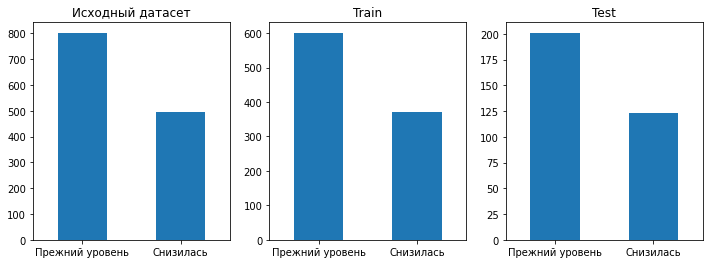

In [70]:
# визуализация баланса целевого признака в выборках
fig, ax = plt.subplots(1,3, figsize=(12,4))
y_data.value_counts().plot(kind='bar', ax=ax[0], rot=0)
ax[0].set_title("Исходный датасет")
y_train_data.value_counts().plot(kind='bar', ax=ax[1], rot=0)
ax[1].set_title("Train")
y_test_data.value_counts().plot(kind='bar', ax=ax[2], rot=0)
ax[2].set_title("Test")
plt.show()

In [71]:
unique_train, counts_train = np.unique(y_train, return_counts=True)
print('Количество значений в тренировочных данных: ',dict(zip(unique_train, counts_train)))
unique_test, counts_test = np.unique(y_test, return_counts=True)
print('Количество значений в тестовых данных: ',dict(zip(unique_test, counts_test)))

Количество значений в тренировочных данных:  {0: 601, 1: 371}
Количество значений в тестовых данных:  {0: 201, 1: 123}


In [72]:
# создаём списки с названиями признаков
ohe_columns = ['тип_сервиса', 'разрешить_сообщать']
ord_columns = ['популярная_категория']
num_columns = df_full.select_dtypes(include=['int64','float64']).columns.tolist()

In [73]:
# создаём пайплайн для подготовки признаков из списка ohe_columns: заполнение пропусков и OHE-кодирование
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False))
    ]
    )

# создаём пайплайн для подготовки признаков из списка ord_columns: заполнение пропусков и Ordinal-кодирование
# SimpleImputer + OE
ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories=[
                    ['Товары для детей',
                     'Домашний текстиль',
                     'Косметика и аксессуары',
                     'Кухонная посуда',
                     'Техника для красоты и здоровья',
                     'Мелкая бытовая техника и электроника'],
                ], 
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

# создаём общий пайплайн для подготовки данных
data_preprocessor = ColumnTransformer(
    [('ohe', ohe_pipe, ohe_columns),
     ('ord', ord_pipe, ord_columns),
     ('num', MinMaxScaler(), num_columns)
    ], 
    remainder='passthrough'
)

# создаём итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
])

In [74]:
param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(2, 10),
        'models__max_features': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    },
    
    # словарь для модели KNeighborsClassifier() 
    {
        'models': [KNeighborsClassifier()],
        'models__n_neighbors': range(2, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']   
    },

    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(1, 10),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    
    # словарь для модели SVC()
    {
        'models': [SVC(random_state=RANDOM_STATE)],
        'models__C': range(1, 10),
        'models__kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), RobustScaler(), 'passthrough']  
    }
]

grid_search = GridSearchCV(
    pipe_final, 
    param_grid=param_grid, 
    cv=5,
    # задайте метрику ROC-AUC
    scoring='roc_auc',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)


print('Лучшая модель и её параметры:\n\n', grid_search.best_estimator_)
print('Параметры лучшей модели:', grid_search.best_params_)
print('Метрика лучшей модели при применении кросс-валидации:', grid_search.best_score_)

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['тип_сервиса',
                                                   'разрешить_сообщать']),
                                                 ('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                     

In [75]:
# подготовка признаков
encoder = OneHotEncoder(drop='first', handle_unknown='error', sparse_output=False)
X_train_ohe = encoder.fit_transform(X_train[ohe_columns])
X_test_ohe = encoder.transform(X_test[ohe_columns])

encoder_col_names = encoder.get_feature_names_out()
    
X_train_ohe = pd.DataFrame(X_train_ohe, columns=encoder_col_names)
X_test_ohe = pd.DataFrame(X_test_ohe, columns=encoder_col_names)

ord_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan)
        
X_train_ord = ord_encoder.fit_transform(X_train[ord_columns])
X_test_ord = ord_encoder.transform(X_test[ord_columns])

X_train_ord = pd.DataFrame(X_train_ord, columns=ord_columns)
X_test_ord = pd.DataFrame(X_test_ord, columns=ord_columns)
    
scaler = StandardScaler()    
    
X_train_scaled = scaler.fit_transform(X_train[num_columns])
X_test_scaled = scaler.transform(X_test[num_columns])    
    
X_train_scaled = pd.DataFrame(X_train_scaled, columns=num_columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=num_columns)    

X_train_for_svc = pd.concat([X_train_ohe, X_train_ord, X_train_scaled], axis=1)
X_test_for_svc = pd.concat([X_test_ohe, X_test_ord, X_test_scaled], axis=1)

In [76]:
#создание объекта для работы с моделью
clf = SVC(kernel='rbf', C=1, probability=True, random_state=RANDOM_STATE)

#обучение модели на данных
clf = clf.fit(X_train_for_svc, y_train)

# Предсказываем значения на тестовой выборке и выводим метрику ROC-AUC
probabilities = clf.predict_proba(X_test_for_svc)
probabilities_one = probabilities[:, 1]
print('Площадь ROC-кривой:', roc_auc_score(y_test, probabilities_one))

Площадь ROC-кривой: 0.9166363305424099


In [77]:
#получение прогнозных меток классов
y_pred = clf.predict(X_test_for_svc)

#вычисление Accuracy
acc = accuracy_score(y_test, y_pred)  
print('Accuracy:', round(acc, 3)) 

#вычисление f1-меры
f1 = f1_score(y_test, y_pred, pos_label=1)  
print('F1-score:', round(f1, 3))

Accuracy: 0.907
F1-score: 0.866


**ROC-AUC** — это всеохватывающая метрика качества классификации. Для тренировочной и тестовой выборок она составляет 0,914 и 0,884 соответственно, что говорит о высоком качестве модели и ее воспроизведении на тестовой выборке. 

**Accuracy** показывает долю верных ответов модели в долях. Результат 0.907 также говорит о хорошем качестве модели.

Precision - эта метрика показывает точность, с которой модель присваивает объектам класс 1.
Recall измеряет, смогла ли модель классификации присвоить класс 1 всем объектам этого класса.

**F1-score**: производная от метрик Precision и Recall. Она агрегирует значения precision и recall в единый показатель качества модели. F1 достигает максимального значения, когда исходные метрики равны единице. Если хотя бы одна из исходных метрик близка к нулю, то и F1 тоже стремится к нулю. Результат данной метрики 0.866 говорит, что модели хорошо присваивает объект класс 1, что говорит о высоком качестве модели.

<div style="border:solid green 2px; padding: 20px">
Вывод: На шаге 5 были обучены 4 модели:
    
- KNeighborsClassifier()
- DecisionTreeClassifier()
- LogisticRegression()
- SVC()
    
Общий пайплайн показал выбор в пользу модели **SVC()**
    
Для модели **SVC()** лучшими параметрами стали:
- С = 1
- kernel = 'rbf'
- preprocessor__num - StandardScaler()
- Метрика лучшей модели на тренировочной выборке: 0.9074669322214778
- Метрика ROC-AUC на тестовой выборке: 0.9166363305424099
- Accuracy: 0,907
- F1-score: 0.866

## Шаг. Анализ важности признаков

In [78]:
print(X_train['тип_сервиса'].value_counts())
print(X_train['разрешить_сообщать'].value_counts())

стандарт    693
премиум     279
Name: тип_сервиса, dtype: int64
да     714
нет    258
Name: разрешить_сообщать, dtype: int64


Отберем количество важных признаков при помощи **SelectKBest()**. SelectKBest составляет свой рейтинг самых значимых признаков и отсеивает все остальные.

### Анализ предсказаний модели

In [79]:
display(X_train_for_svc)

,тип_сервиса_стандарт,разрешить_сообщать_нет,популярная_категория,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц,минут_за_пред_месяц,минут_за_текущ_месяц
0,1.0,0.0,3.0,1.228498,-0.034940,-0.386673,-0.678649,-0.926450,0.554520,1.446808,1.973431,0.308218,-1.451803,0.921997,1.641373,-1.744172
1,1.0,0.0,4.0,0.829033,-0.034940,-1.626840,-0.354956,0.559539,1.048557,-1.130716,-1.316315,2.067366,-0.714636,-1.724921,-0.647600,-0.064910
2,1.0,0.0,3.0,0.030104,1.380136,1.555325,-0.597726,1.302533,-0.927589,-0.615212,0.708144,-1.204835,-0.629125,-1.714569,-0.138940,-0.784593
3,1.0,0.0,2.0,1.328364,-0.034940,-1.056603,2.517826,-0.926450,2.036630,0.415798,-0.051028,-0.035885,1.266868,-0.562990,0.115391,1.374458
4,0.0,0.0,5.0,-0.668960,1.380136,1.060853,0.292432,-0.183455,-0.433553,-1.130716,-0.810200,-1.772856,-0.437461,-0.760751,-0.901931,-0.784593
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
967,1.0,0.0,1.0,-0.269495,-1.450017,-0.697712,-0.638188,0.559539,-0.927589,-1.130716,1.214259,0.989271,-0.455153,1.630697,0.878382,2.094141
968,1.0,0.0,3.0,-0.768826,-0.034940,0.235404,-0.435879,-0.926450,-0.433553,-1.130716,-0.051028,-0.412181,0.862901,-1.005869,1.895703,1.134563
969,1.0,0.0,5.0,1.028765,-0.034940,-1.016726,-0.759573,-1.669444,2.036630,-0.615212,0.455087,0.595806,1.281611,0.412484,0.369721,1.374458
970,1.0,1.0,3.0,0.329702,-0.034940,1.168520,-0.638188,1.302533,-1.421625,1.962313,-0.051028,-0.133178,0.429447,-0.421155,1.132712,1.614352


Заменим наименования двух столбцов, которые обрабатывались в OneHotEncoder на первоначальные для лучшей визуализации.

In [80]:
#создадим списки показателей
k = [] #количество признаков
roc_auc_train = [] #показатель roc-auc для тренировочной выборки
roc_auc_test = [] #показатель roc-auc для тестовой выборки
accs = [] #показатель accuracy
f_score = [] #показатель f1-score
priz_names = [] #перечень признаков

#Обучаем модель
clf_select = SVC(kernel='rbf', C=1, probability=True, random_state=RANDOM_STATE)  

for i in range(1, 17):
    #селектор
    selector = SelectKBest(f_classif, k=i)

    #применяем SelectKBest к набору тренировочных данных
    X_train_select = selector.fit_transform(X_train_for_svc, y_train)
    
    #применяем SelectKBest к набору тестовых данных
    X_test_select = selector.transform(X_test_for_svc)
    
    #обучаем SVC на отобранных признаках
    clf_select.fit(X_train_select, y_train)
    
    #применяем SVC к тестовым данным
    y_pred_select = clf_select.predict(X_test_select)
    
    index = selector.get_support(indices=True)
    
    k.append(i)
    
    #выводим значения roc-auc
    roc_auc_train.append(round(cross_val_score(clf_select, X_train_select, y_train,\
                                               scoring='roc_auc').mean(), 3))  
    probabilities = clf_select.predict_proba(X_test_select)
    probabilities_one = probabilities[:, 1]
    roc_auc_test.append(round(roc_auc_score(y_test, probabilities_one), 3))
    
    #выводим accuracy
    accs.append(round(accuracy_score(y_test, y_pred_select), 3))
    
    #выводим f1-score
    f_score.append(round(f1_score(y_test, y_pred_select, pos_label=1), 3))
              
    #извлекаем названия выбранных признаков из исходного датасета
    feature_names = X_train_for_svc.columns[index].tolist()
    
    priz_names.append(feature_names)
              
#создаем отдельный датасет для метрик
metric = pd.DataFrame({'k': k,
                       'ROC_AUC_train': roc_auc_train,
                       'ROC_AUC_test': roc_auc_test,
                       'Accuracy': accs,
                       'f1_score': f_score,
                       'Признаки': priz_names
                       
                       }
                     )
              
display(metric)

,k,ROC_AUC_train,ROC_AUC_test,Accuracy,f1_score,Признаки
0,1,0.819,0.846,0.802,0.712,[страниц_за_визит]
1,2,0.857,0.873,0.861,0.796,"[страниц_за_визит, минут_за_пред_месяц]"
2,3,0.866,0.876,0.907,0.867,"[страниц_за_визит, минут_за_пред_месяц, минут_..."
3,4,0.873,0.893,0.901,0.857,"[акционные_покупки, страниц_за_визит, минут_за..."
4,5,0.868,0.897,0.910,0.872,"[маркет_актив_6_мес, акционные_покупки, страни..."
5,6,0.880,0.914,0.904,0.862,"[маркет_актив_6_мес, акционные_покупки, средни..."
6,7,0.889,0.914,0.914,0.876,"[маркет_актив_6_мес, акционные_покупки, средни..."
7,8,0.902,0.921,0.914,0.876,"[маркет_актив_6_мес, акционные_покупки, средни..."
8,9,0.906,0.920,0.914,0.876,"[маркет_актив_6_мес, акционные_покупки, средни..."
9,10,0.906,0.920,0.914,0.876,"[тип_сервиса_стандарт, маркет_актив_6_мес, акц..."


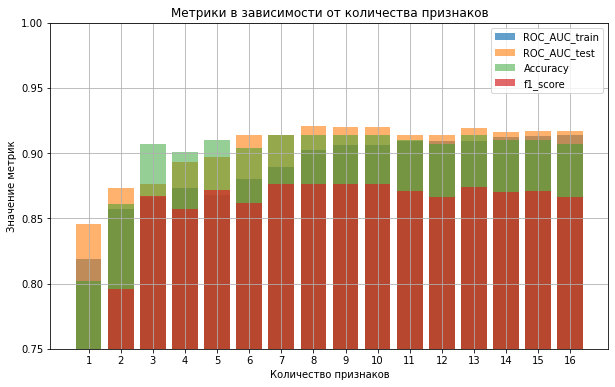

In [81]:
# Создаем гистограмму
plt.figure(figsize=(10, 6))

# Гистограмма ROC-AUC на тренировочной выборке
plt.bar(metric['k'], metric['ROC_AUC_train'], label='ROC_AUC_train', alpha=0.7)

# Гистограмма ROC-AUC на тестовой выборке
plt.bar(metric['k'], metric['ROC_AUC_test'], label='ROC_AUC_test', alpha=0.6)

# Гистограмма Accuracy
plt.bar(metric['k'], metric['Accuracy'], label='Accuracy', alpha=0.5)

# Гистограмма F1-меры
plt.bar(metric['k'], metric['f1_score'], label='f1_score', alpha=0.7)

# Добавляем заголовок
plt.title('Метрики в зависимости от количества признаков')

# Добавляем метки осей
plt.xlabel('Количество признаков')
plt.ylabel('Значение метрик')

# Устанавливаем лимиты для оси x
plt.xticks(range(1, 17))

# Устанавливаем лимиты для оси y
plt.ylim(0.75, 1)

# Добавляем легенду
plt.legend()

# Показываем гистограмму
plt.grid(True)
plt.show()

Выводим максимальные значения метрик:

In [82]:
max_ROC_AUC_test = metric['ROC_AUC_test'].max()
max_acc = metric['Accuracy'].max()
max_f1 = metric['f1_score'].max()
print('максимальная ROC-AUC_test:',max_ROC_AUC_test)
print('максимальная Accuracy:',max_acc)
print('максимальная f1 - score:',metric['f1_score'].max())

максимальная ROC-AUC_test: 0.921
максимальная Accuracy: 0.914
максимальная f1 - score: 0.876


In [83]:
best_metric = metric.query('ROC_AUC_test==@max_ROC_AUC_test')
display(best_metric)

,k,ROC_AUC_train,ROC_AUC_test,Accuracy,f1_score,Признаки
7,8,0.902,0.921,0.914,0.876,"[маркет_актив_6_мес, акционные_покупки, средни..."


Проверим состав признаков.

In [84]:
best_metric['Признаки'].tolist()

[['маркет_актив_6_мес',
  'акционные_покупки',
  'средний_просмотр_категорий_за_визит',
  'неоплаченные_продукты_штук_квартал',
  'страниц_за_визит',
  'выручка_за_препред_месяц',
  'минут_за_пред_месяц',
  'минут_за_текущ_месяц']]

**Важность признаков для линейных SVM можно определить, но не для нелинейных SVM (у нас 'rbf', т.е. нелинейное). Причина в том, что при нелинейном SVM набор данных отображается в пространство более высокой размерности, которое сильно отличается от исходного набора данных, и получается гиперплоскость, а также данные более высокой размерности и, следовательно, свойства, которые отличаются от свойств исходного набора данных, поэтому невозможно определить важность признаков для этого SVM по отношению к признакам исходного набора данных.**

### Проверка permutation importance

**Permutation importance** подсвечивает качество модели с ещё одной стороны. Он показывает, насколько изменятся метрики, если поочерёдно рандомизировать каждый входной признак модели.

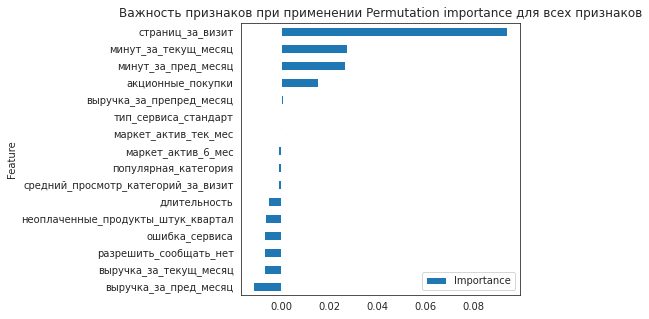

In [85]:
#модель
clf = SVC(kernel='rbf', C=1, probability=True, random_state=RANDOM_STATE)

#имена признаков
features_names = X_train_for_svc.columns

#обучение модели
clf.fit(X_train_for_svc, y_train)

def custom_f1(model, X, y):
    y_pred = model.predict(X)
    score = f1_score(y, y_pred)
    return score

result = permutation_importance(clf, X_test_for_svc, y_test, scoring=custom_f1)

feature_importance = pd.DataFrame({'Feature': features_names, 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Feature', y='Importance', kind='barh',\
                        figsize=(5, 5)).\
set_title("Важность признаков при применении Permutation importance для всех признаков");

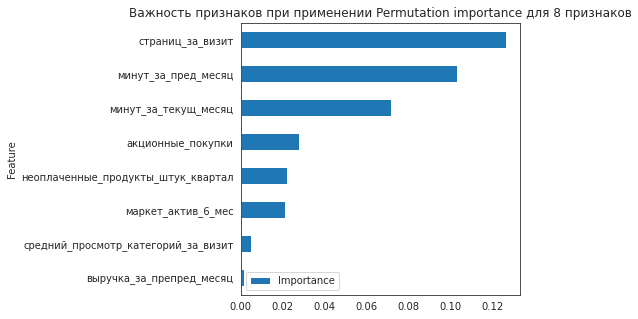

In [86]:
# инициализируем селектор и модель со значением k=8
selector = SelectKBest(f_classif, k=8)
model_8 = SVC(kernel='rbf', C=1, probability=True, random_state=RANDOM_STATE)

# обучаем SelectKBest
selector.fit(X_train_for_svc, y_train)

#применяем SelectKBest к набору тренировочных данных
X_train_select_8 = selector.fit_transform(X_train_for_svc, y_train)

#применяем SelectKBest к набору тестовых данных
X_test_select_8 = selector.transform(X_test_for_svc)

# формируем выборки с лучшими признаками
features_names = X_train_for_svc.columns[selector.get_support(indices=True)]
X_train_8 = X_train_for_svc[list(features_names)]
X_test_8 = X_test_for_svc[list(features_names)]

# обучаем модель
model_8.fit(X_train_8, y_train)

result = permutation_importance(model_8, X_test_8, y_test, scoring=custom_f1)

feature_importance = pd.DataFrame({'Feature': features_names, 'Importance': result['importances_mean']})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
sns.set_style('white')
feature_importance.plot(x='Feature', y='Importance', kind='barh',\
                        figsize=(5, 5)).set_title("Важность признаков при применении Permutation importance для 8 признаков");

**В ТОП-5 наиболее влияющих признаков вошли при применении только модели SVC:**

- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
- значение времени, проведённого на сайте, в минутах (предыдущий месяц)
- значение времени, проведённого на сайте, в минутах (текущий месяц)
- среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)

**Наименее значимыми для модели стали:**

- выручка за текущий месяц
- неоплаченные продукты
- популярная категория
- информация о том, можно ли присылать покупателю дополнительные предложения о товаре (cогласие на это даёт покупатель)
- значение, которое показывает, сколько дней прошло с момента регистрации покупателя на сайте

**В ТОП-5 наиболее влияющих признаков вошли при применении SelectKBest (8 признаков):**

- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
- значение времени, проведённого на сайте, в минутах (предыдущий месяц)
- значение времени, проведённого на сайте, в минутах (текущий месяц)
- среднемесячная доля покупок по акции от общего числа покупок за последние 6 месяцев
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)

**Наименее значимым для модели с SelectKBest()(8 признаков) стал:**

- средний просмотр категорий за визит

### Анализ SHAP-значений

Однозначную оценку вклада признака в каждый прогноз показывают значения Шепли, их оценивают методом **SHAP (SHapley Additive exPlanations)**. Он вычисляет, как отдельный признак помог присвоить модели итоговое значение целевого.

In [87]:
def shap_plot (model,X_train,X_test):
    sample = shap.sample(X_train, nsamples=10, random_state=RANDOM_STATE)

    # Инициализируем KernelExplainer с суммарным фоном
    explainer = shap.KernelExplainer(model.predict, sample)

    # Вычисляем SHAP значения
    shap_values = explainer(X_test)

    # Визуализируем SHAP значений с помощью графика beeswarm
    shap.plots.beeswarm(shap_values, max_display=16);

Построим график для изначальной модели без SelectKBest().

  0%|          | 0/324 [00:00<?, ?it/s]

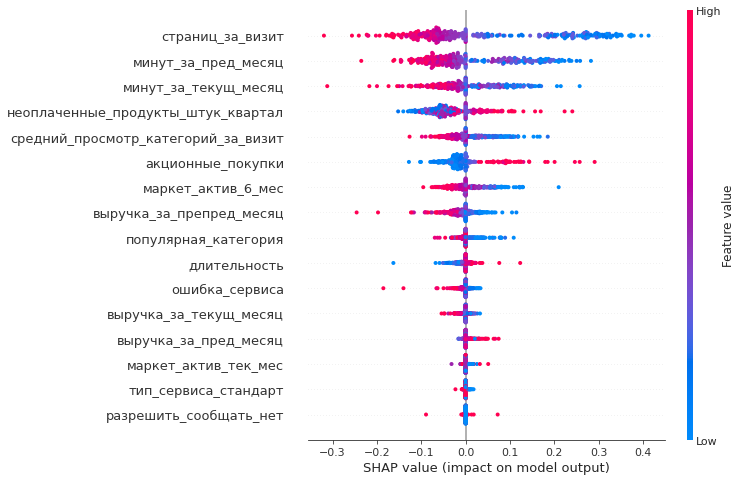

In [88]:
shap_plot(clf,X_train_for_svc,X_test_for_svc)

Теперь построим график для 8 отобранных признаков.

  0%|          | 0/324 [00:00<?, ?it/s]

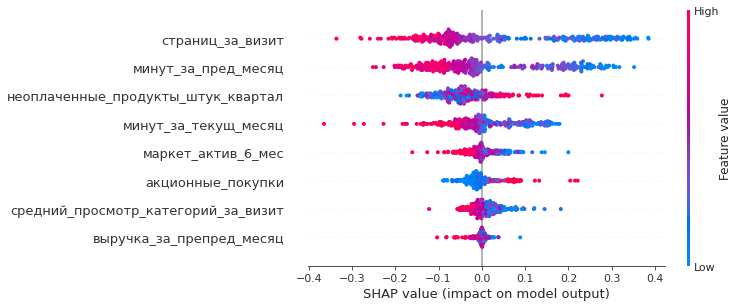

In [89]:
shap_plot(model_8,X_train_8,X_test_8)

- значения слева от центральной вертикальной линии — это negative класс (0), справа — positive (1)
- чем толще линия на графике, тем больше таких точек наблюдения
- чем краснее точки на графике, тем выше значения признака в ней

**Метод SHAP для всех признаков модели SVC включил в ТОП-5 признаков:**

- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца (чем больше просмотренных страниц, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- значение времени, проведённого на сайте, в минутах (предыдущий месяц) (чем больше количество времени, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- значение времени, проведённого на сайте, в минутах (текущий месяц) (чем больше количество времени, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- общее число неоплаченных товаров в корзине за последние 3 месяца (чем меньше количество, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- средний просмотр категорий за визит (чем выше количество, тем больше вероятность отнесения к классу «Прежний уровень» (0))

**Наименее значимыми для модели стали:**

- выручка за предыдущий месяц
- выручка за текущий месяц
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)
- тип сервиса
- информация о том, можно ли присылать покупателю дополнительные предложения о товаре (согласие на это даёт покупатель)

**Метод SHAP для всех признаков модели SVC с SelectKBest()(8 признаков) включил в ТОП-5 признаков:**

- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца (чем больше просмотренных страниц, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- значение времени, проведённого на сайте, в минутах (предыдущий месяц) (чем больше количество времени, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- общее число неоплаченных товаров в корзине за последние 3 месяца (чем меньше количество, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- значение времени, проведённого на сайте, в минутах (текущий месяц) (чем больше количество времени, тем больше вероятность отнесения к классу «Прежний уровень» (0))
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента) (чем выше значение, тем больше вероятность отнесения к классу «Прежний уровень» (0))

**Наименее значимыми для модели с SelectKBest()(8 признаков) стали:**

- выручка за предыдущий месяц


<div style="border:solid green 2px; padding: 20px">
Вывод: на шаге 6 была оценена важность признаков для лучшей модели (SVC) и построены графики важности permutation importance и SHAP.
    
Наиболее значимыми признаками, влияющими на результат, стали:
    
- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
- значение времени, проведённого на сайте, в минутах (предыдущий месяц)
- значение времени, проведённого на сайте, в минутах (текущий месяц)
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)

Наименее значимые признаки расходятся при использовании различных методов.
    
Таким образом, необходимо улучшить количество маркетинговых коммуникаций с покупателями.


## Шаг. Сегментация покупателей

В качестве основных сегментов покупателей, расматриваются:

- Группа клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности.
- Группа клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом.
- Группа клиентов, которые покупают товары из категории «Товары для себя» (новая категория, которую можно выделить на основе текущих) или «Товары для детей».
- Группа клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью.

Будем работать с моделью SVC() c использованием SelectKBest() (8 признаков).

На данный момент у нас есть:
    
- общий датасет 'market'
- модель SVC() c SelectKBest(f_classif, k=8)
- X_train_8 c отбором лучших десяти признаков
- X_test_8 c отбором лучших 8 признаков

Также необходимо получить данные из изначальных датасетов 'X_train' и 'X_test' данные о значении индекса строки для дальнейшего объединения.

In [90]:
X_train = X_train.reset_index()
X_test = X_test.reset_index()

In [91]:
#выводим значения целевых признаков для тренировочных данных на основании модели
y_train_8_proba = model_8.predict_proba(X_train_8)[:,1]
y_train_8_pred = model_8.predict(X_train_8)

#выводим значения целевых признаков для тестовых данных на основании модели
y_test_8_proba = model_8.predict_proba(X_test_8)[:,1]
y_test_8_pred = model_8.predict(X_test_8)

#объединим данные с целевым признаком
X_train['y_proba'] = y_train_8_proba.tolist()
X_train['y_pred'] = y_train_8_pred.tolist()

X_test['y_proba'] = y_test_8_proba.tolist()
X_test['y_pred'] = y_test_8_pred.tolist()

all_data = pd.concat([X_train,X_test],axis=0)

In [92]:
all_data.shape

(1296, 19)

In [93]:
all_data = all_data.sort_values('index')
all_data = all_data.reset_index()
market['вероятность'] = all_data['y_proba']
market['прогноз'] = all_data['y_pred']
market['прогноз'] = market['прогноз'].apply(lambda x: 'Снизилась' if x == 1 else 'Прежний уровень')
display(market)

,id,покупательская_активность,тип_сервиса,разрешить_сообщать,маркет_актив_6_мес,маркет_актив_тек_мес,длительность,акционные_покупки,популярная_категория,средний_просмотр_категорий_за_визит,неоплаченные_продукты_штук_квартал,ошибка_сервиса,страниц_за_визит,выручка_за_пред_месяц,выручка_за_препред_месяц,выручка_за_текущ_месяц,минут_за_пред_месяц,минут_за_текущ_месяц,вероятность,прогноз
0,215349,Снизилась,премиум,да,4.4,4,819,0.75,Товары для детей,4,4,2,5,5216.0,4472.0,4971.6,12,10,0.961176,Снизилась
1,215350,Снизилась,стандарт,нет,4.9,3,539,0.14,Домашний текстиль,5,2,1,5,5457.5,4826.0,5058.4,8,13,0.265616,Прежний уровень
2,215351,Снизилась,стандарт,да,3.2,5,896,0.99,Товары для детей,5,0,6,4,6158.0,4793.0,6610.4,11,13,0.797702,Снизилась
3,215352,Снизилась,стандарт,нет,5.1,3,1064,0.94,Товары для детей,3,2,3,2,5807.5,4594.0,5872.5,8,11,0.962620,Снизилась
4,215353,Снизилась,стандарт,да,3.3,4,762,0.26,Домашний текстиль,4,1,1,4,4738.5,5124.0,5388.5,10,10,0.818575,Снизилась
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1291,216643,Прежний уровень,стандарт,да,6.6,3,318,0.24,Техника для красоты и здоровья,5,3,3,11,3664.0,4704.0,4741.7,14,7,0.091951,Прежний уровень
1292,216644,Прежний уровень,стандарт,нет,5.1,4,454,0.21,Домашний текстиль,6,2,3,9,4729.0,5299.0,5353.0,12,11,0.078386,Прежний уровень
1293,216645,Прежний уровень,стандарт,да,4.1,3,586,0.20,Домашний текстиль,3,2,5,7,5160.0,5334.0,5139.2,12,18,0.045207,Прежний уровень
1294,216646,Прежний уровень,стандарт,да,6.3,5,645,0.12,Техника для красоты и здоровья,3,3,5,7,4923.0,4725.0,5224.6,18,7,0.130281,Прежний уровень


### Анализ группы клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности

Еще на этапе исследовательского анализа было отмечено черьезное влияние доли акционных покупок на состояние покупательской активности. Применение Permutation importance для всех лучшей модели подтвердило важность этого признака.

In [94]:
market['акционные_покупки'].value_counts().reset_index().sort_values('index')

,index,акционные_покупки
13,0.11,31
22,0.12,20
7,0.13,64
5,0.14,69
10,0.15,49
8,0.16,62
3,0.17,79
20,0.18,23
32,0.19,11
21,0.20,21


Максимальная доля акционных покупок составляет 0,99. Но доля покупателей выйдет маленькая и на графиках будет некорректное отображение.

Отберем покупателей с максимальной долей покупок и высокой вероятностью снижения покупательской активности (группа 1). 

In [95]:
market_akc = market.query('акционные_покупки>=0.6 and прогноз=="Снизилась"')

In [96]:
print('Количество подходящих в группу покупателей: ',market_akc.shape[0])

Количество подходящих в группу покупателей:  121


Выделим еще одну группу покупателей (доля акционных покупок ниже 0,6 и низкая вероятность по снижению покупательской активности) (группа 2).

In [97]:
market_no_akc = market.query('акционные_покупки<0.6 and прогноз!="Снизилась"')

Проанализируем гистограммы для количественных признаков.

In [98]:
list_num = market_akc.drop(['id','акционные_покупки','вероятность'], axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()
def group_plot(data_1,data_2,str):
    fig, axes = plt.subplots(str, 2, figsize=(15, 30))

    # Преобразование 2D массива подграфиков в 1D для удобного индексирования
    axes = axes.ravel()

    for i, column in enumerate(list_num):
        #считаем среднее и медианное значение для выборок
        mean_1 = np.mean(data_1[column])
        median_1 = np.median(data_1[column])
        mean_2 = np.mean(data_2[column])
        median_2 = np.median(data_2[column])
    
        #строим графики для изучаемой группы покупателей
        sns.histplot(data_1[column], bins=70, color='orange', alpha=0.8, label='Группа 1', kde=True, ax=axes[i])
        axes[i].axvline(mean_1, color='orange', linestyle='dashed', linewidth=1,\
                        label=f'Среднее для группы 1: {mean_1:.2f}')
        axes[i].axvline(median_1, color='red', linestyle='dashed', linewidth=1,\
                        label=f'Медиана для группы 1: {median_1:.2f}');
    
        #строим графики для противопоставимой группы покупателей
        sns.histplot(data_2[column], bins=70, color='aquamarine', alpha=0.8,\
                     label='Группа 2', kde=True, ax=axes[i])
        axes[i].axvline(mean_2, color='blue', linestyle='dashed', linewidth=1,\
                        label=f'Среднее для группы 2: {mean_2:.2f}')
        axes[i].axvline(median_2, color='green', linestyle='dashed', linewidth=1,\
                        label=f'Медиана для группы 2: {median_2:.2f}');
        axes[i].legend(loc = 'upper left')

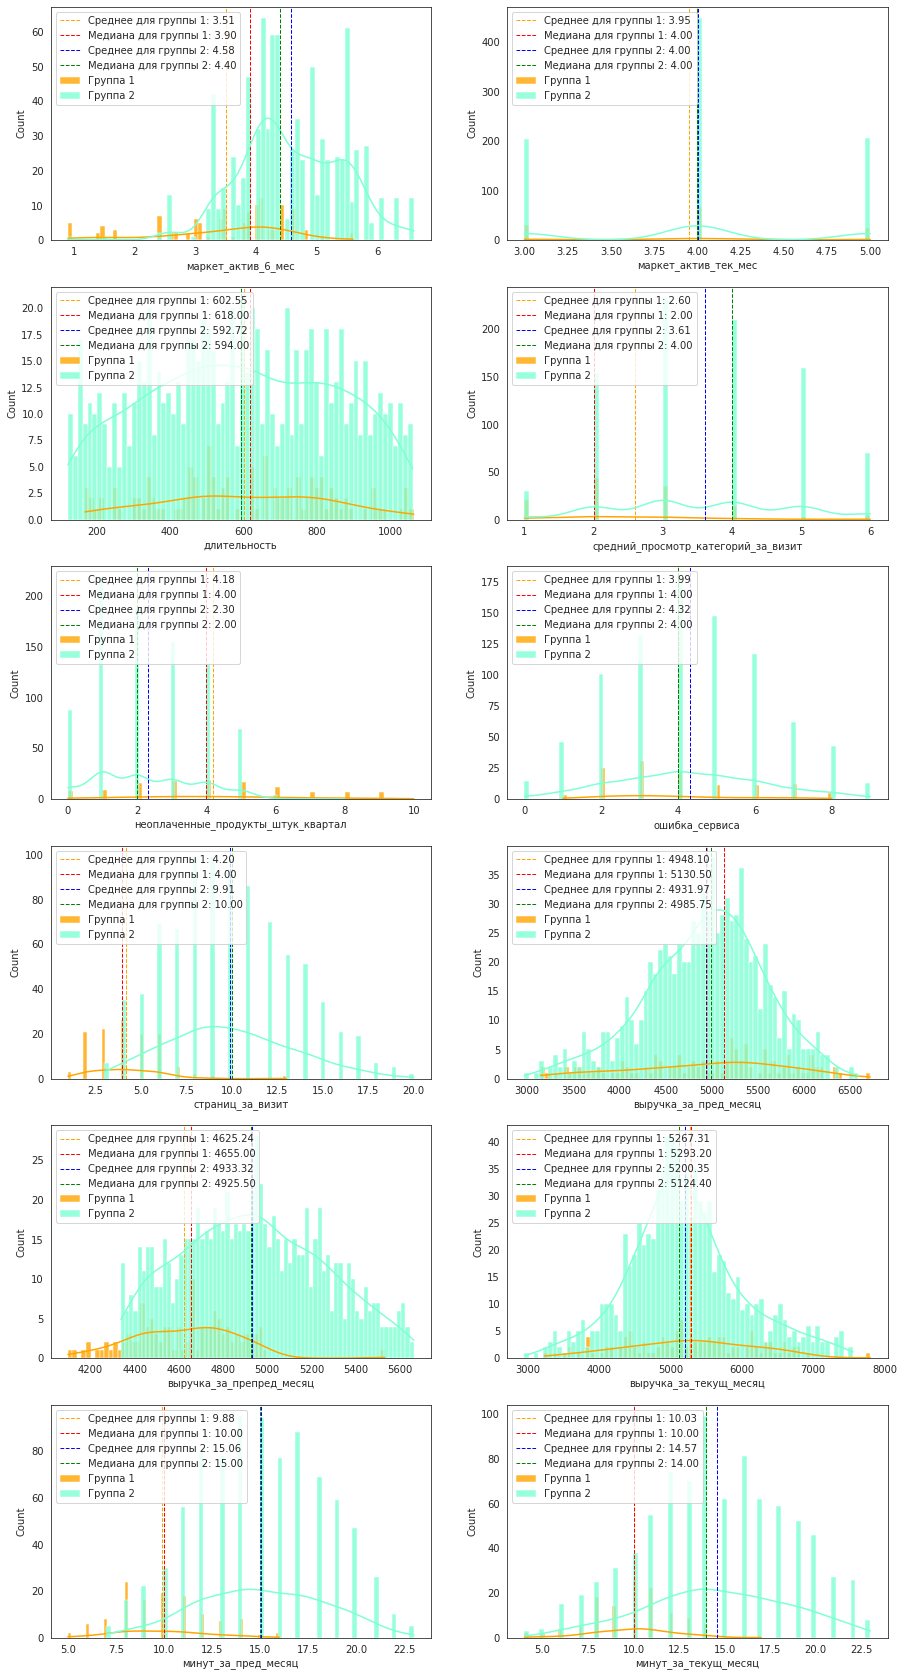

In [99]:
group_plot(market_akc,market_no_akc,6)

Проанализируем ситуацию для групп по категориальным признакам.

In [100]:
list_cat = ['тип_сервиса','разрешить_сообщать','популярная_категория']
def group_bar(data_1,data_2):
    for name in list_cat:
        table_akc = round(pd.DataFrame(data_1[name].value_counts(normalize=True)*100).reset_index(),2)
        table_akc['группа'] = 'Группа 1'
        table_no_akc = round(pd.DataFrame(data_2[name].value_counts(normalize=True)*100).reset_index(),2)
        table_no_akc['группа'] = 'Группа 2'
        table=pd.concat([table_akc,table_no_akc], axis=0)
        table.rename(columns={'index': name, name: '%'}, inplace=True)

        plt.figure(figsize=(10, 5)) 
        splot = sns.barplot(x=name, y="%", hue="группа", 
                        data=table, palette='Greens') 
  
        for p in splot.patches: 
            splot.annotate(format(p.get_height()), 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 9), 
                       textcoords='offset points') 
      
        plt.ylabel("% от числа покупателей", size=14)
        plt.ylim(0, 90)
        plt.xticks(rotation=60)
        plt.title(name, size=18);

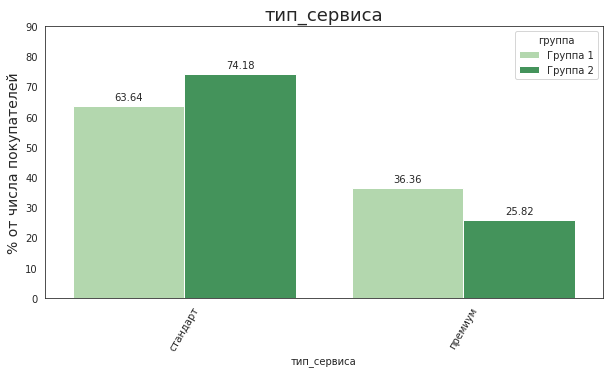

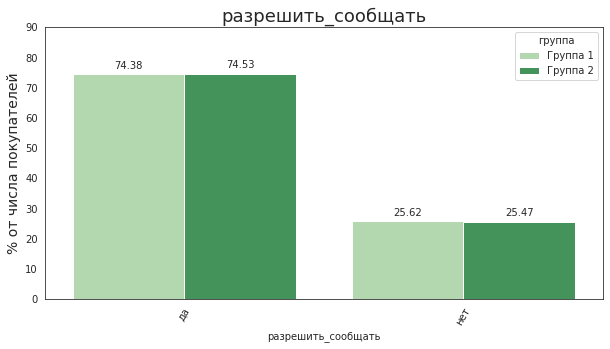

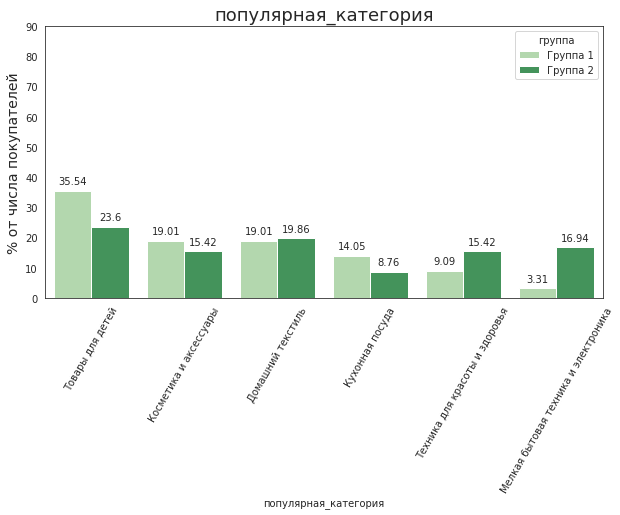

In [101]:
group_bar(market_akc,market_no_akc)

Проанализируем изменение в выручке между периодами для разных категорий.

In [102]:
def plot_sales(data_1,data_2):
    for name in list_cat:
        table_1 = data_1.pivot_table(index=name, values=['выручка_за_пред_месяц',
                                                                   'выручка_за_препред_месяц',
                                                                   'выручка_за_текущ_месяц'], aggfunc='median').reset_index()
        for i in table_1[name].unique():
            table_1[name] = table_1[name].replace(i, i+'+снизилась медиана')

        table_2 = data_2.pivot_table(index=name, values=['выручка_за_пред_месяц',
                                                                   'выручка_за_препред_месяц',
                                                                   'выручка_за_текущ_месяц'], aggfunc='median').reset_index()
        for i in table_2[name].unique():
            table_2[name] = table_2[name].replace(i, i+'+прежний уровень медиана')

        table = pd.concat([table_1,table_2],axis =0)
        table = table[[name,'выручка_за_препред_месяц','выручка_за_пред_месяц','выручка_за_текущ_месяц']]
        table= table.set_index(name,drop=True).transpose()
        table.reset_index(inplace=True)
        list = table.drop('index',axis=1).columns
        plt.figure(figsize=(10,8))
        col = (np.random.random (), np.random.random (), np.random.random ())
        for i in list:
            r = random.random()  # генерирует случайное число в диапазоне от 0 до 1
            g = random.random()
            b = random.random()
            color = (r, g, b)
            plt.plot(table['index'],table[i],label = i, marker='o', color=color)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title('График по значениями медианы выручки по категории "'+name+'"', fontdict = {'fontsize' : 20});

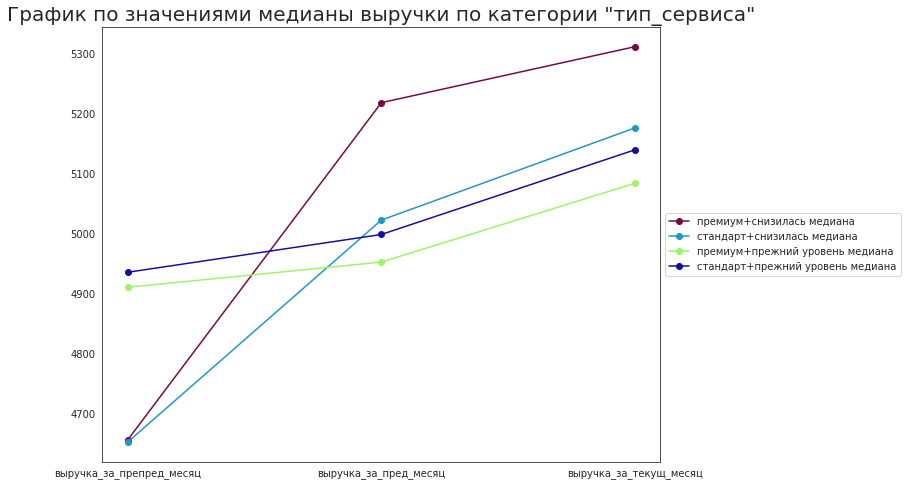

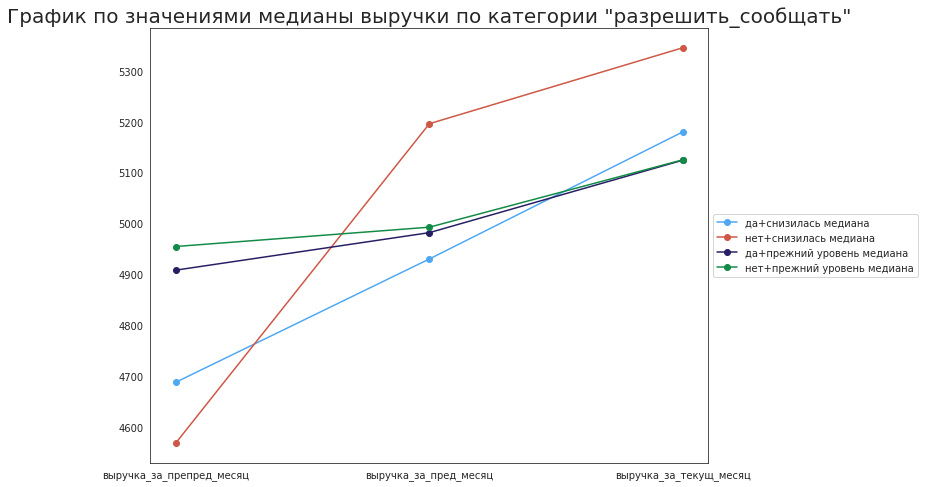

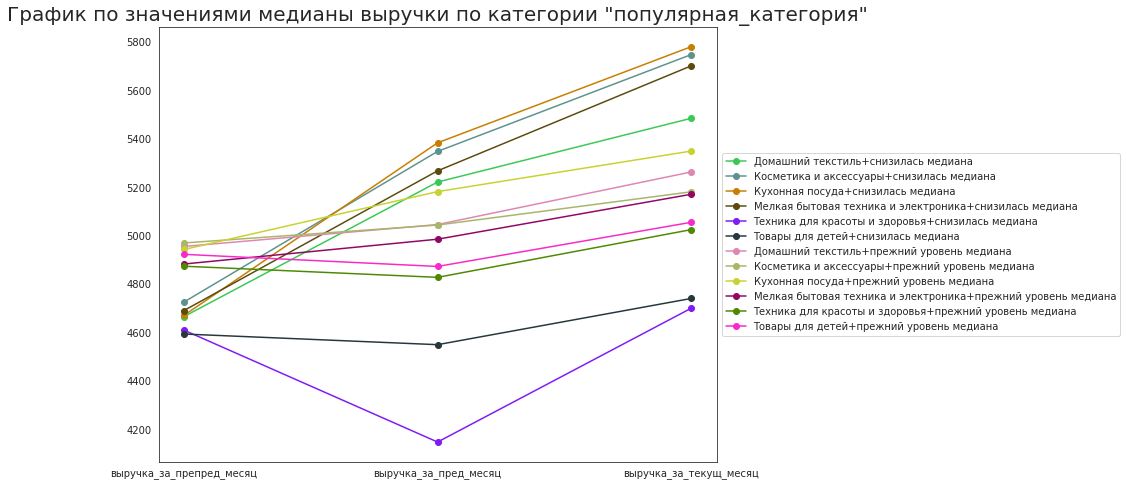

In [103]:
plot_sales(market_akc,market_no_akc)

Падение выручки по месяцам в разрезе категорий наблюдается в предыдущий месяц (для группы покупателей со снизившейся покупательской активностью: домашний текстиль, косметика и аксессуары и техника для красоты и здоровья).

Группа 1 явно нацелена именно на покупки акционных товаров. Отсюда и показатели количества страниц. Необходимо рассмотреть возможность новых акций в совокупности с сохранением выручки. Необходимо увеличить рассылку об акционных товарах для это группы. Особое внимание необходимо обратить на категории товаров, по которым в предыдущем месяце снизилась покупательская активность, чтобы в будущем это не повторялось.


### Анализ группы клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом

In [104]:
market_tec = market.query('популярная_категория=="Техника для красоты и здоровья"\
or популярная_категория=="Мелкая бытовая техника и электроника"')
market_tec = market_tec.query('прогноз=="Снизилась"')

In [105]:
print('Количество подходящих в группу покупателей: ',market_tec.shape[0])

Количество подходящих в группу покупателей:  56


Выделим еще одну группу покупателей (интерес к товарам для детей, косметике и аксессуарам и кухонной посуде и низкая вероятность по снижению покупательской активности).

In [106]:
market_no_tec = market.query('популярная_категория!="Техника для красоты и здоровья"\
and популярная_категория!="Мелкая бытовая техника и электроника"')
market_no_tec = market_no_tec.query('прогноз=="Прежний уровень"')

Построим гистограммы распределения для количественных признаков.

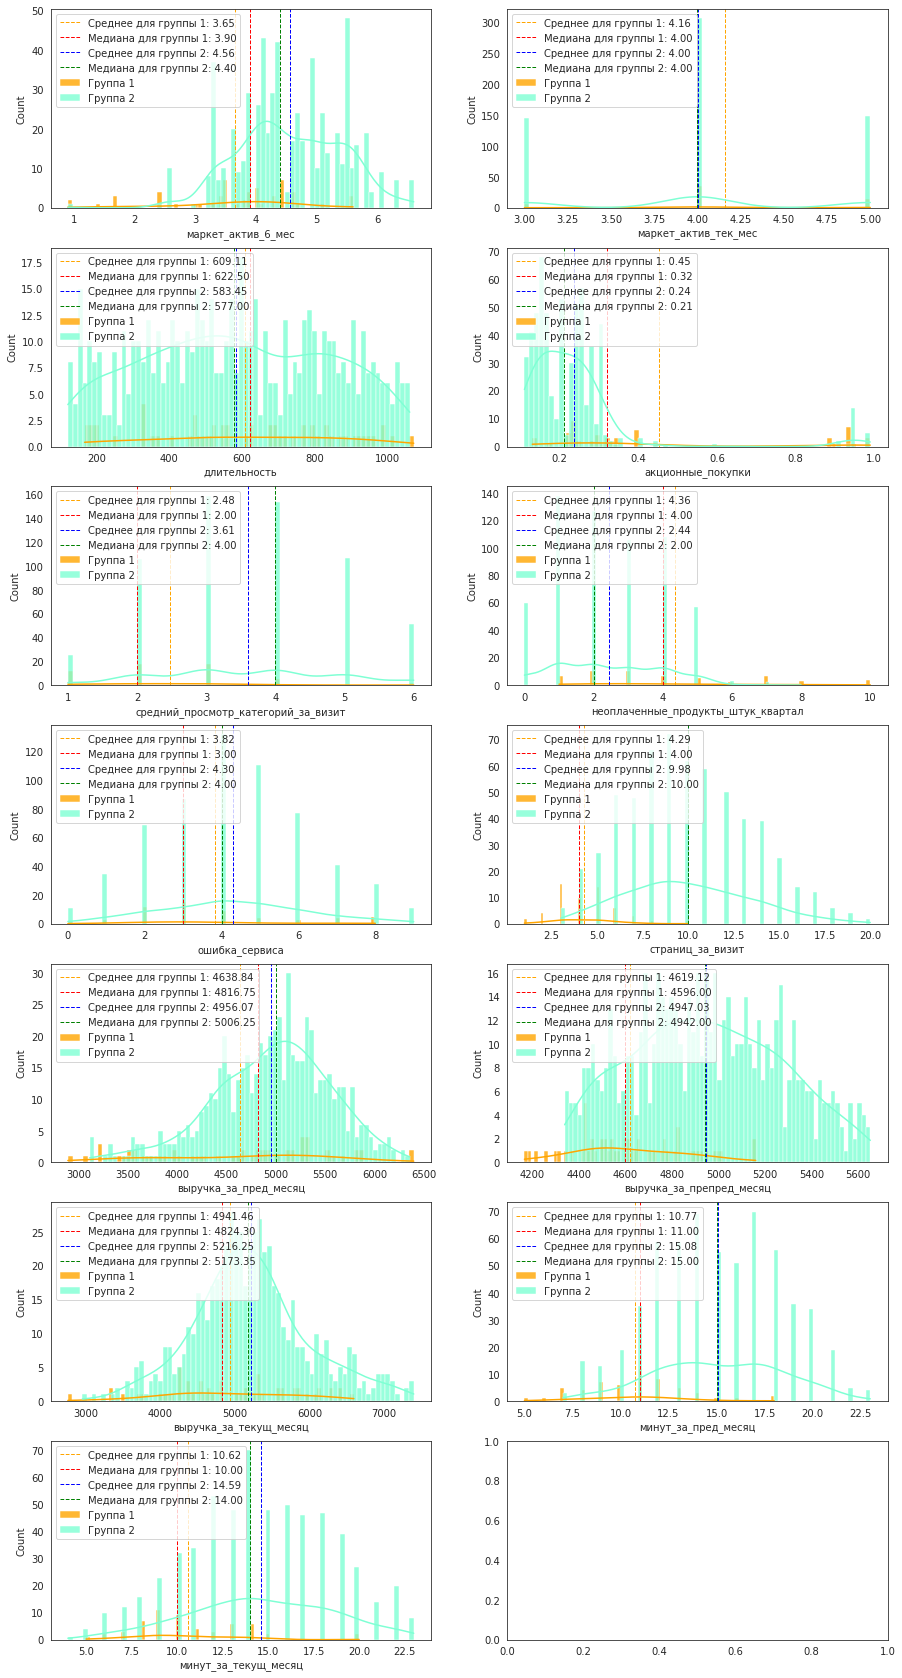

In [107]:
list_num = market_tec.drop(['id','популярная_категория','вероятность'], axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()
group_plot(market_tec,market_no_tec,7)

Построим столбчатые диаграммы для качественных признаков.

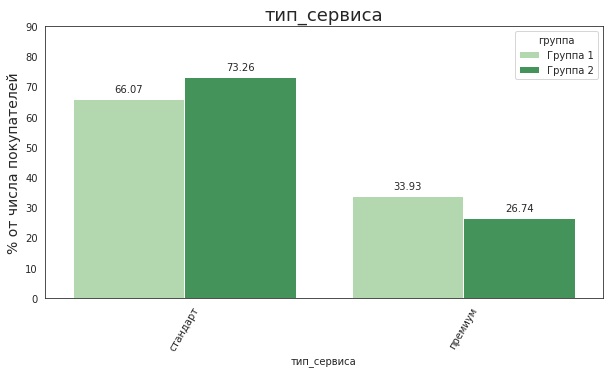

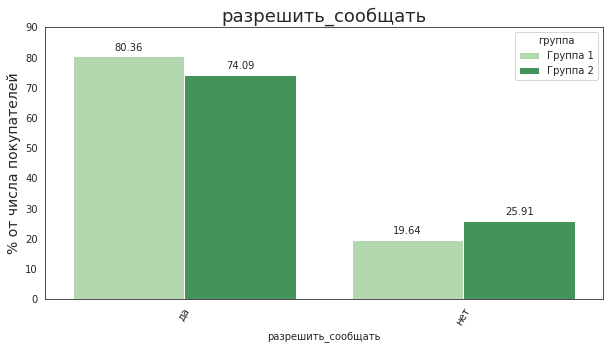

In [108]:
list_cat = ['тип_сервиса','разрешить_сообщать'] 
group_bar(market_tec,market_no_tec)

Проанализируем изменение в выручке между периодами для разных категорий.

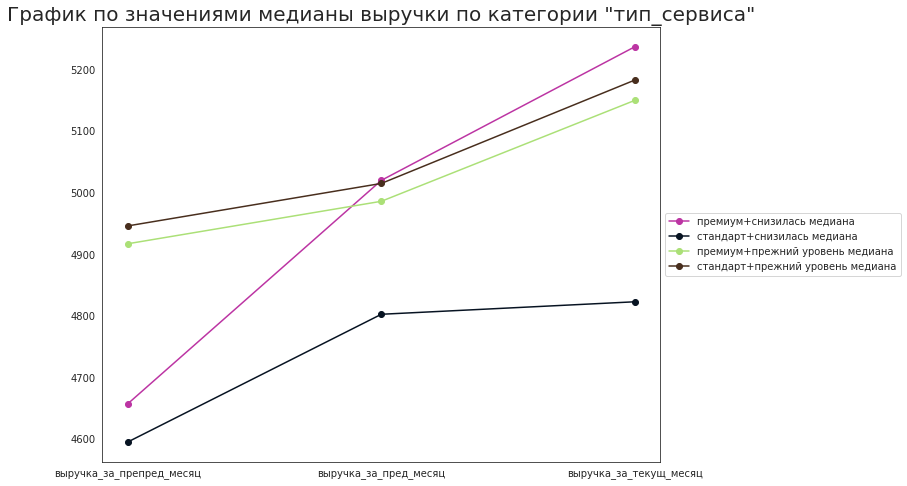

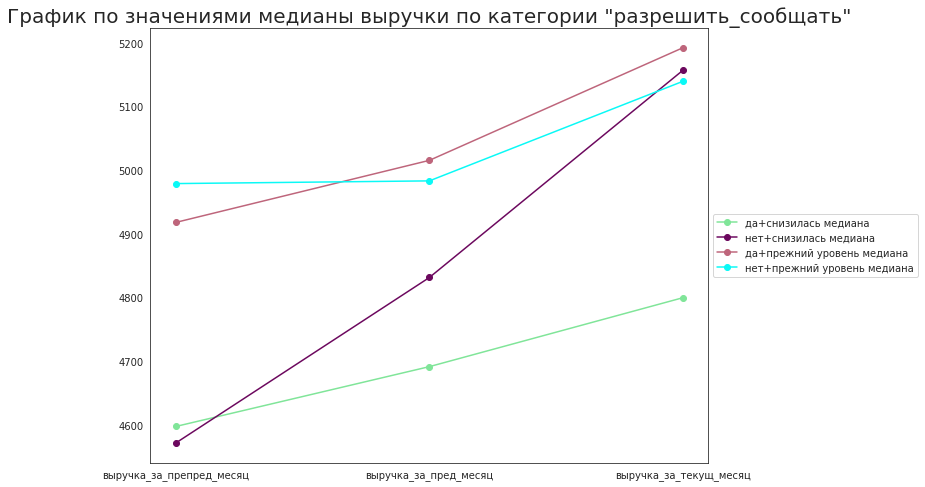

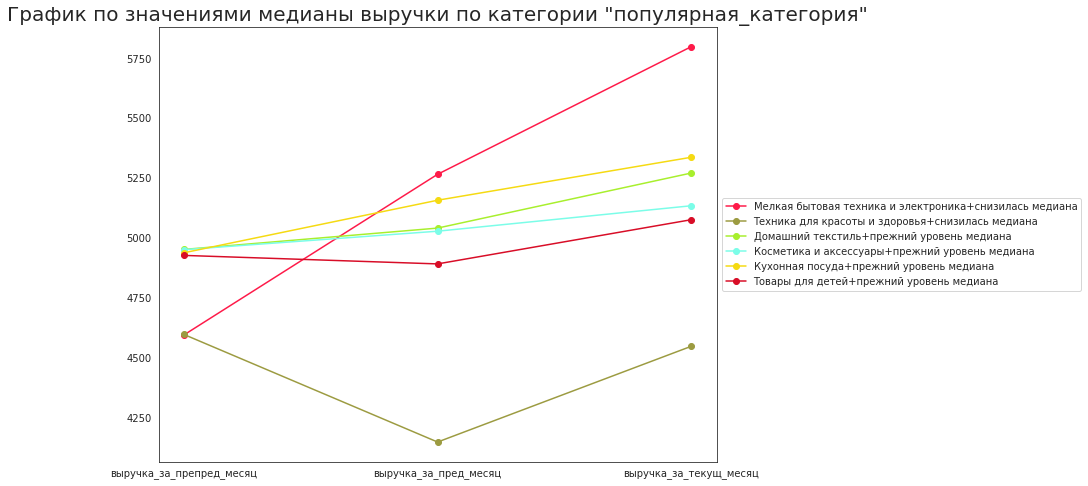

In [109]:
list_cat = ['тип_сервиса','разрешить_сообщать','популярная_категория'] 
plot_sales(market_tec,market_no_tec)

Падение выручки по месяцам в разрезе категорий наблюдается в предыдущий месяц (для группы покупателей со снизившейся покупательской активностью: техника для красоты и здоровья)

Здесь возможно расширение раздела продаж техники. Но необходимо быть осторожным, соблюдая принцип себестоимость изменений/выручка. Необходимо улучшить качество системы информирования о дополнительных товарах. Особенно комментарии касаются категории товаров со снизившейся покупательской активностью в предыдущем месяце, чтобы избегать этого в дальнейшем.

### Анализ группы клиентов, которые покупают товары из категории «Товары для себя» или «Товары для детей»

В новую группу исследования выберем:
- Товары для детей
- Косметика и аксессуары

In [110]:
market_self = market.query('популярная_категория=="Товары для детей" or популярная_категория=="Косметика и аксессуары"')
market_self = market_self.query('прогноз=="Снизилась"')

In [111]:
print('Количество подходящих в группу покупателей: ',market_self.shape[0])

Количество подходящих в группу покупателей:  205


Выделим еще одну группу покупателей (интерес к технике, домашнему текстилю и кухонно посуде и низкая вероятность по снижению покупательской активности).

In [112]:
market_no_self = market.query('популярная_категория!="Товары для детей" and популярная_категория!="Косметика и аксессуары"')
market_no_self = market_no_self.query('прогноз!="Снизилась"')

Построим гистограммы распределения для количественных признаков.

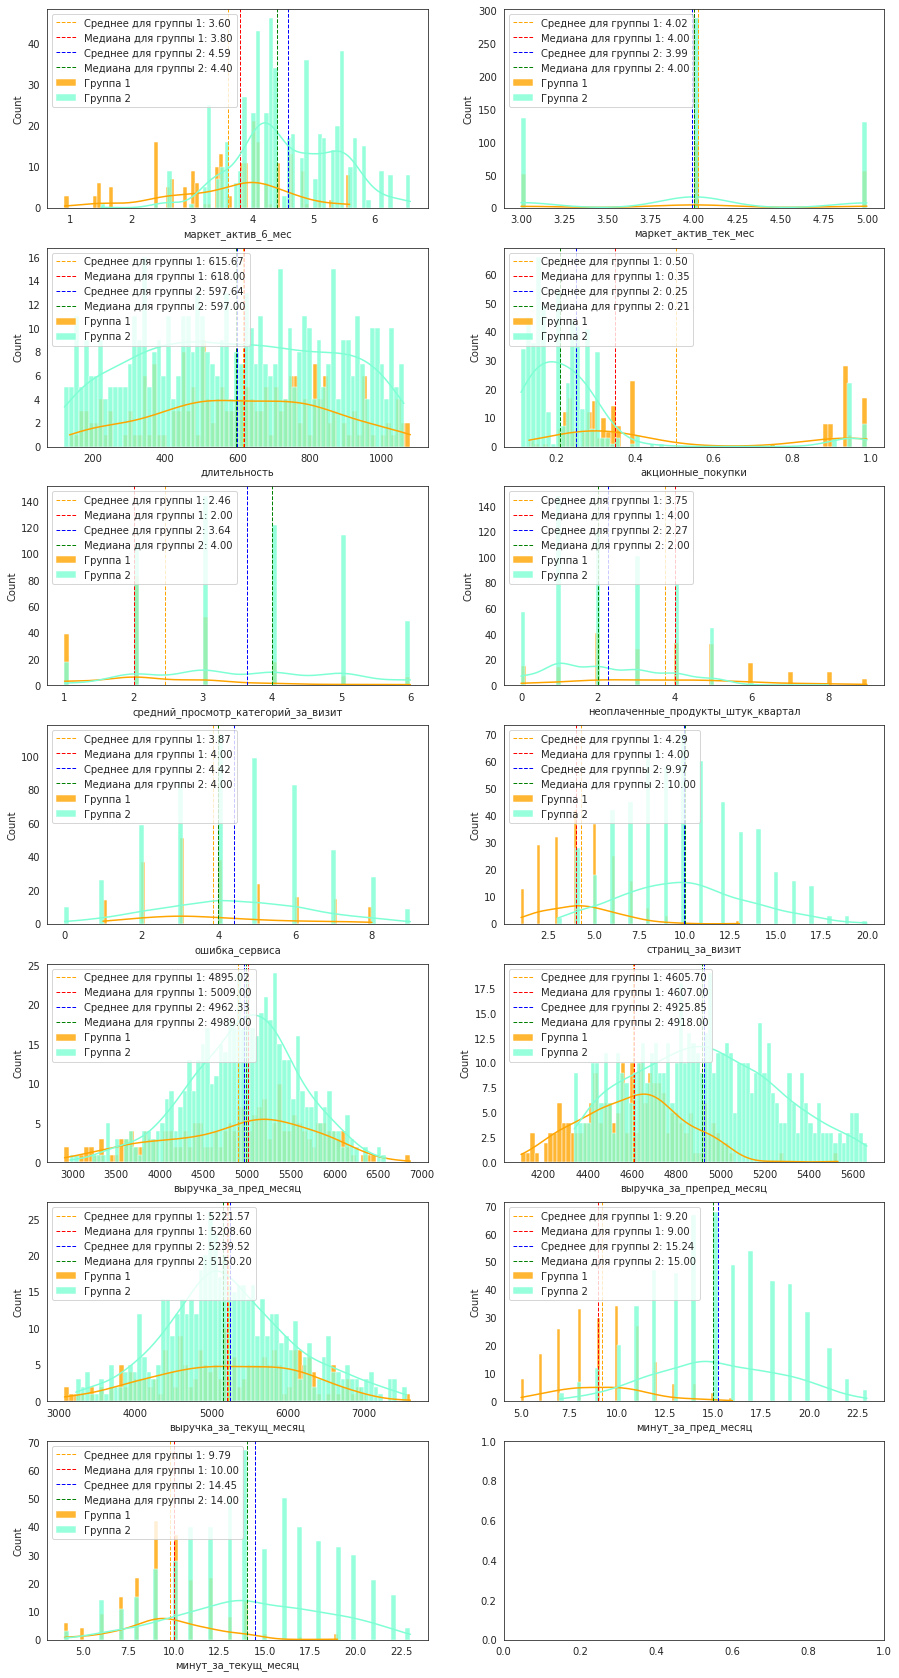

In [113]:
list_num = market_self.drop(['id','популярная_категория','вероятность'], axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()
group_plot(market_self,market_no_self,7)

Построим столбчатые диаграммы для качественных признаков.

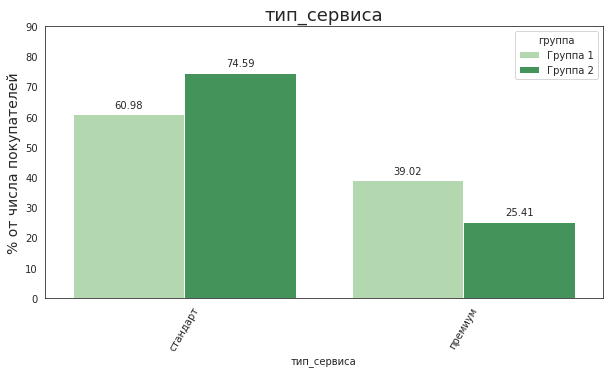

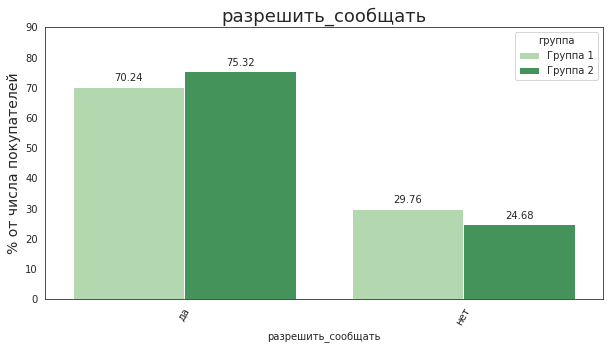

In [114]:
list_cat = ['тип_сервиса','разрешить_сообщать'] 
group_bar(market_self,market_no_self)

Проанализируем изменение в выручке между периодами для разных категорий.

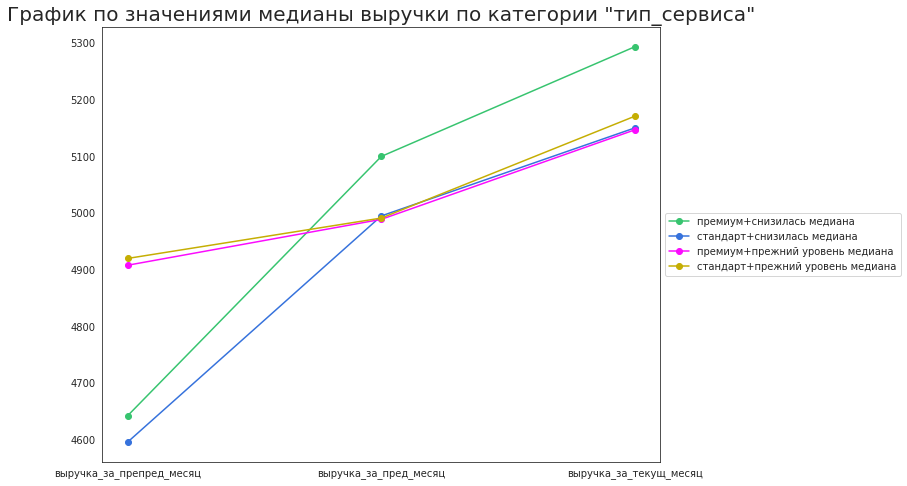

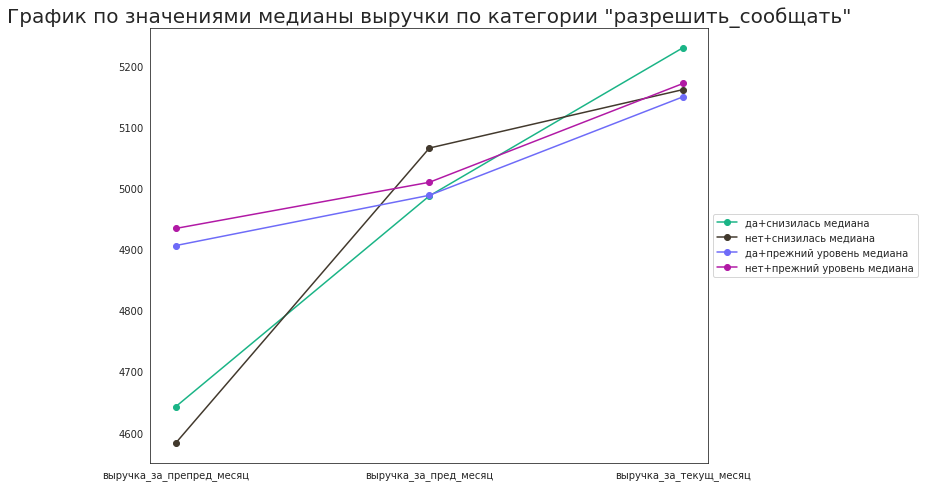

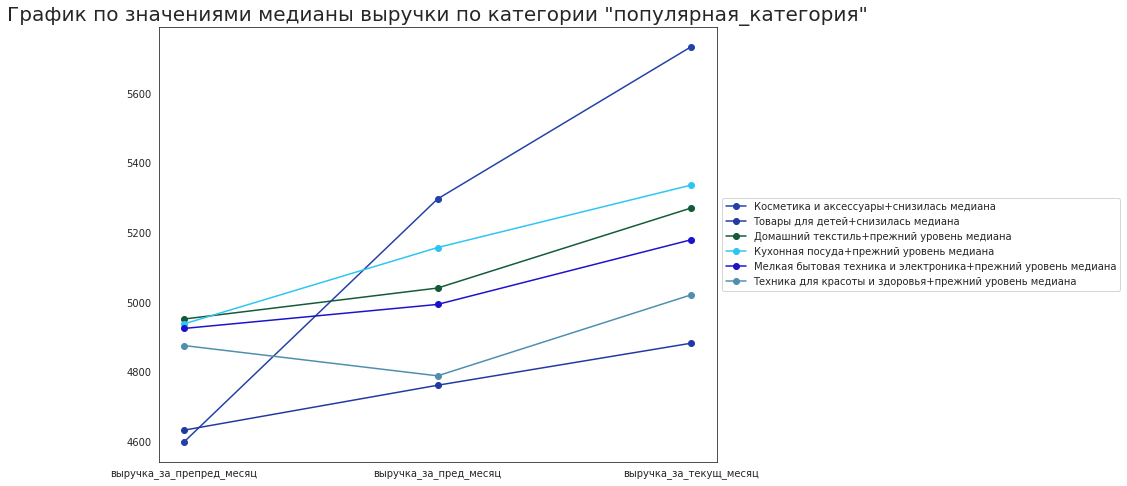

In [115]:
list_cat = ['тип_сервиса','разрешить_сообщать','популярная_категория'] 
plot_sales(market_self,market_no_self)

Просадки выручки для группы покупателей со снизившейся покупательской активностью не наблюдается, но наблюдается опять просадка выручки по категории 'техника для красоты и здоровья'.

Необходимо увеличить маркетинговые коммуникации с покупателями для группы 1. Покупатели данной группы явно ждут скидок на товары, которые их интересуют (возможно, определенные товары закупают впрок). Особенное внимание, опять же стоит обратить на раздел техники для красоты и здоровья.

### Анализ группы клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью

Создадим новый столбец в датасете 'market' с данными об общей прибыльности.

In [116]:
market['прибыльность'] = market['выручка_за_пред_месяц']+market['выручка_за_препред_месяц']+market['выручка_за_текущ_месяц']

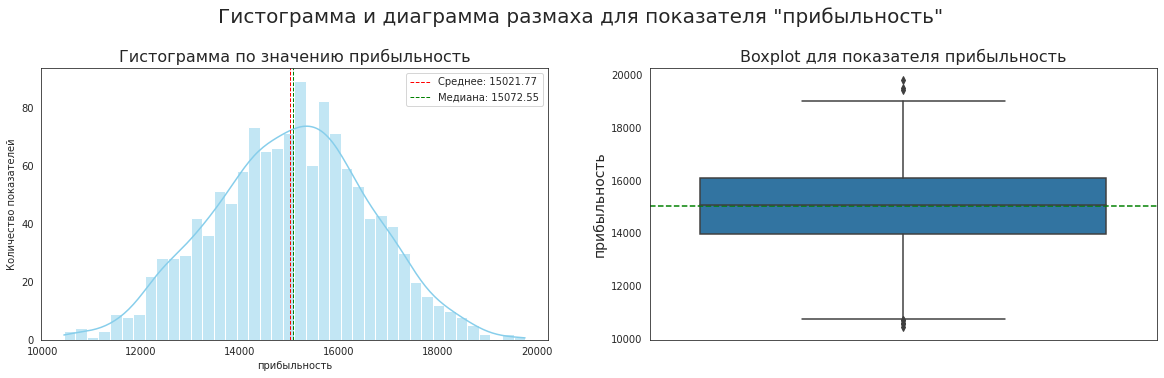

In [117]:
hist_plot(market,'прибыльность',40)

Отберем значения прибыльности выше 16000.

In [118]:
market_max_sales = market.query('прибыльность>16000')

In [119]:
market_max_sales = market_max_sales.query('прогноз=="Снизилась"')

In [120]:
print('Количество подходящих в группу покупателей: ',market_max_sales.shape[0])

Количество подходящих в группу покупателей:  119


Выделим еще одну группу покупателей (прибыльность ниже 16000 и низкая вероятность по снижению покупательской активности).

In [121]:
market_min_sales = market.query('прибыльность<=16000 and прогноз=="Прежний уровень"')

Построим гистограммы распределения для количественных признаков.

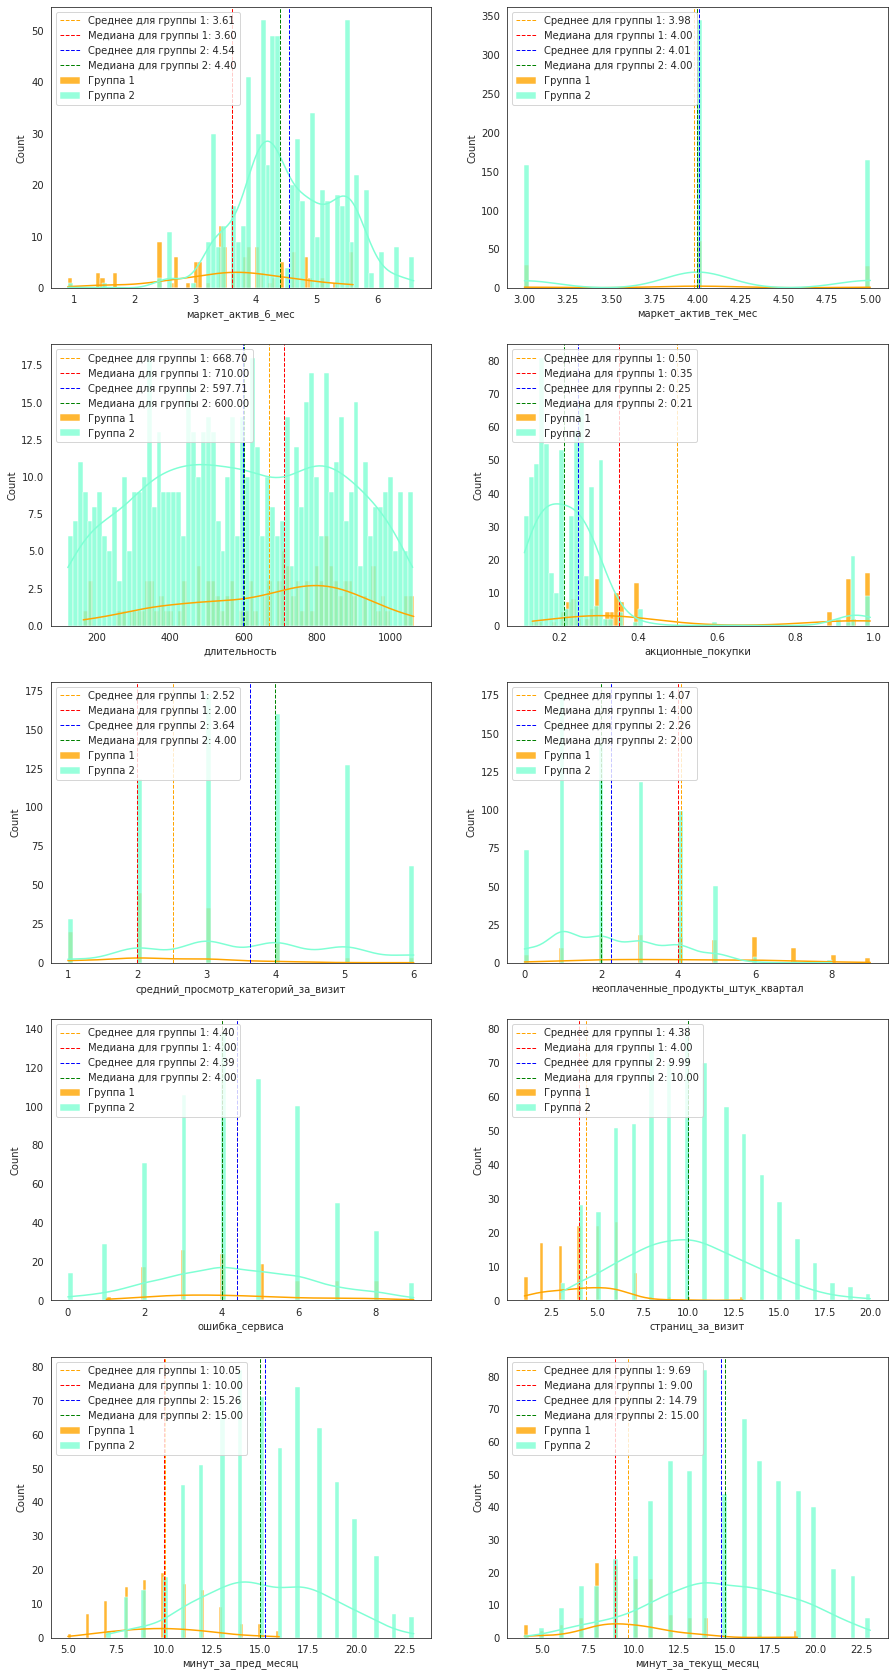

In [122]:
list_num = market_max_sales.drop(['id','прибыльность','вероятность','выручка_за_пред_месяц',\
                                  'выручка_за_препред_месяц','выручка_за_текущ_месяц'], axis=1).\
select_dtypes(include=['int64','float64']).columns.tolist()
group_plot(market_max_sales,market_min_sales,5)

Построим столбчатые диаграммы для качественных признаков.

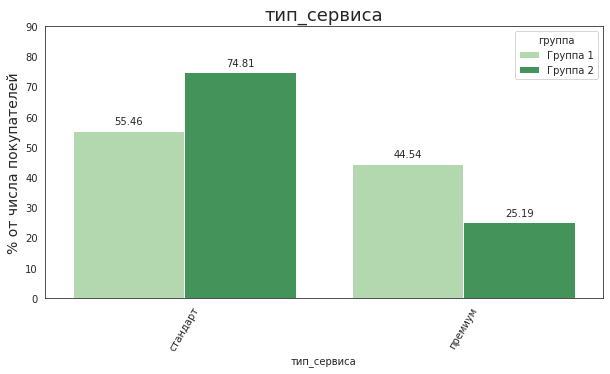

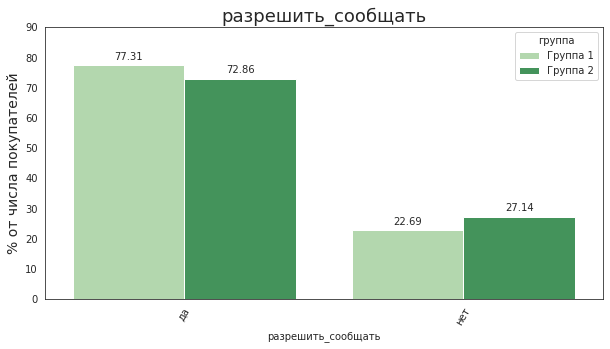

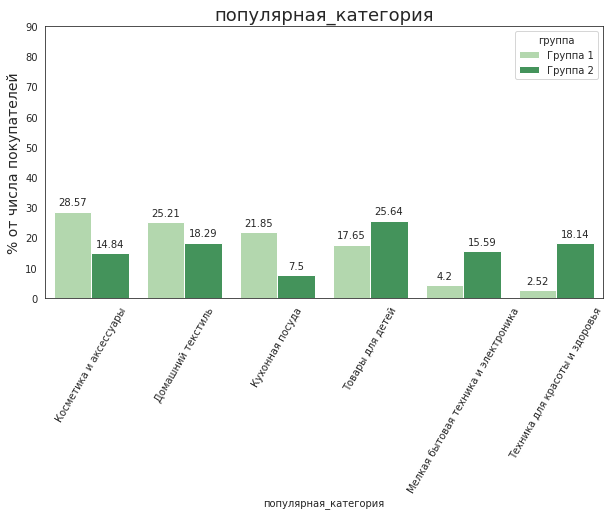

In [123]:
list_cat = ['тип_сервиса','разрешить_сообщать','популярная_категория'] 
group_bar(market_max_sales,market_min_sales)

Проанализируем изменение в выручке между периодами для разных категорий.

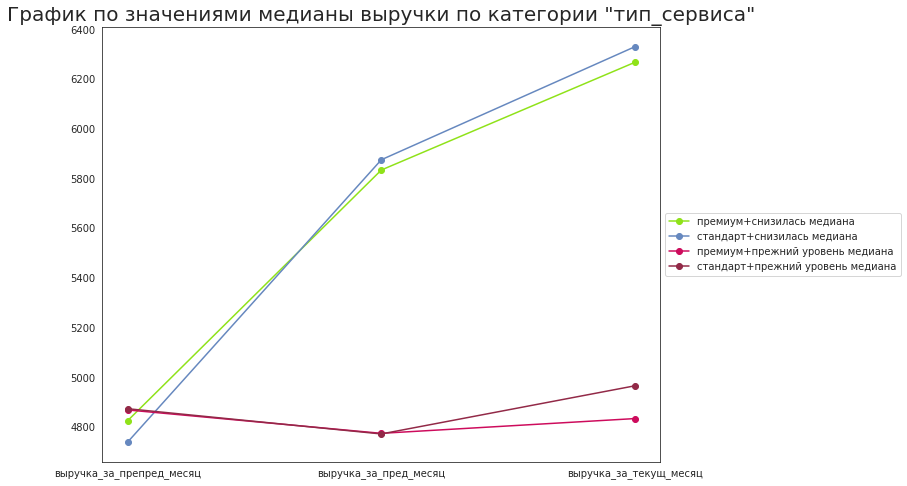

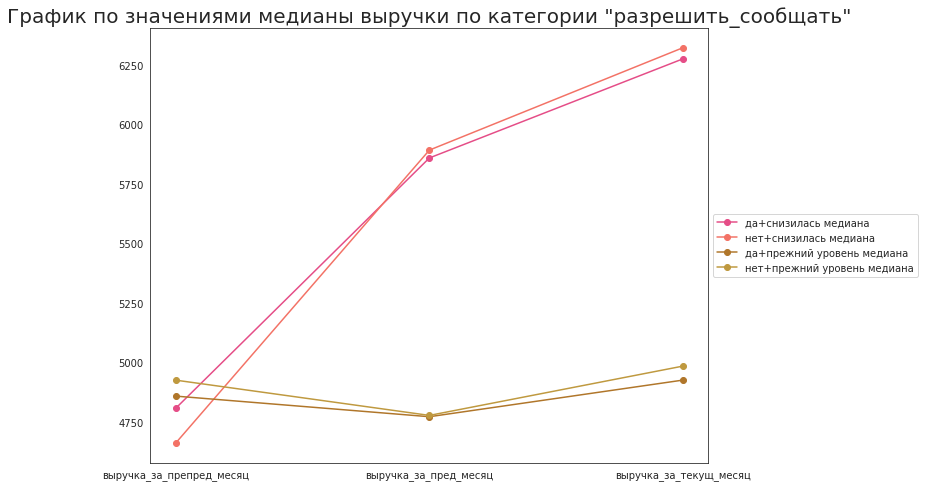

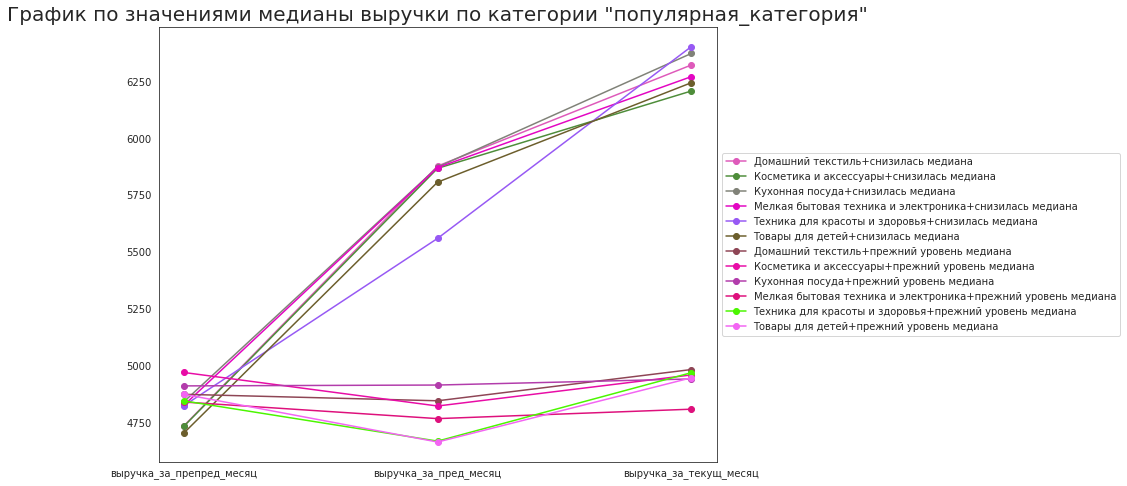

In [124]:
plot_sales(market_max_sales,market_min_sales)

Просадки выручки для группы покупателей со снизившейся покупательской активностью не наблюдается, но наблюдается опять просадка выручки по категории 'техника для красоты и здоровья'.

Необходимо увеличить маркетинговые коммуникации с покупателями для группы 1. Сосредоточиться в рассылке необходимо на товарах из категорий «Домашний текстиль», «Кухонная посуда» и «Косметика и аксессуары»

### Анализ группы клиентов с высокой вероятностью снижения покупательской активности и меньшим уровнем маркетинговых коммуникаций за последние 6 месяцев

Данная группа покупателей была выбрана по следующим причинам:
- признаки отобранные в результате анализа permutation importance (для всех признаков и 8 наиболее влияющих при применении SelectKBest()) и SHAP:
    - среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
    - значение времени, проведённого на сайте, в минутах (предыдущий месяц)
    - значение времени, проведённого на сайте, в минутах (текущий месяц)
    - среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)
Но первые три это скорее показатели, что снижение активности уже идет.
Маркетинговые коммуникации демонстрируют взаимодействие самой компании с покупателями.


Отберем показатели 'маркет_актив_6_мес', т.к. показатель 'маркет_актив_тек_мес' сопоставим для покупателей со снижением покупательской активности и ее прежним уровнем.

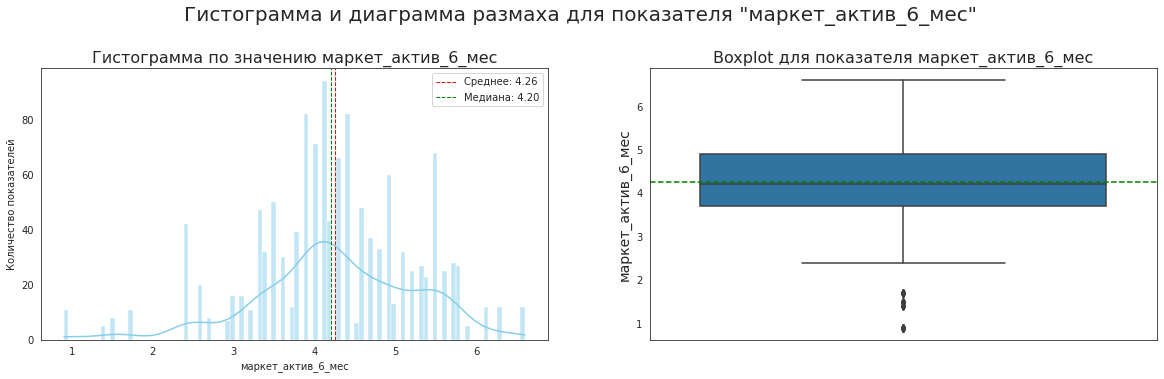

In [125]:
hist_plot(market,'маркет_актив_6_мес',100)

Отберем значения ниже медианного для новой исследуемой группы 1.

In [126]:
market_min_aktiv = market.query('маркет_актив_6_мес<4.2 and прогноз=="Снизилась"')

In [127]:
print('Количество подходящих в группу покупателей: ',market_min_aktiv.shape[0])

Количество подходящих в группу покупателей:  304


In [128]:
market_max_aktiv = market.query('маркет_актив_6_мес>=4.2 and прогноз=="Прежний уровень"')

Построим гистограммы распределения для количественных признаков.

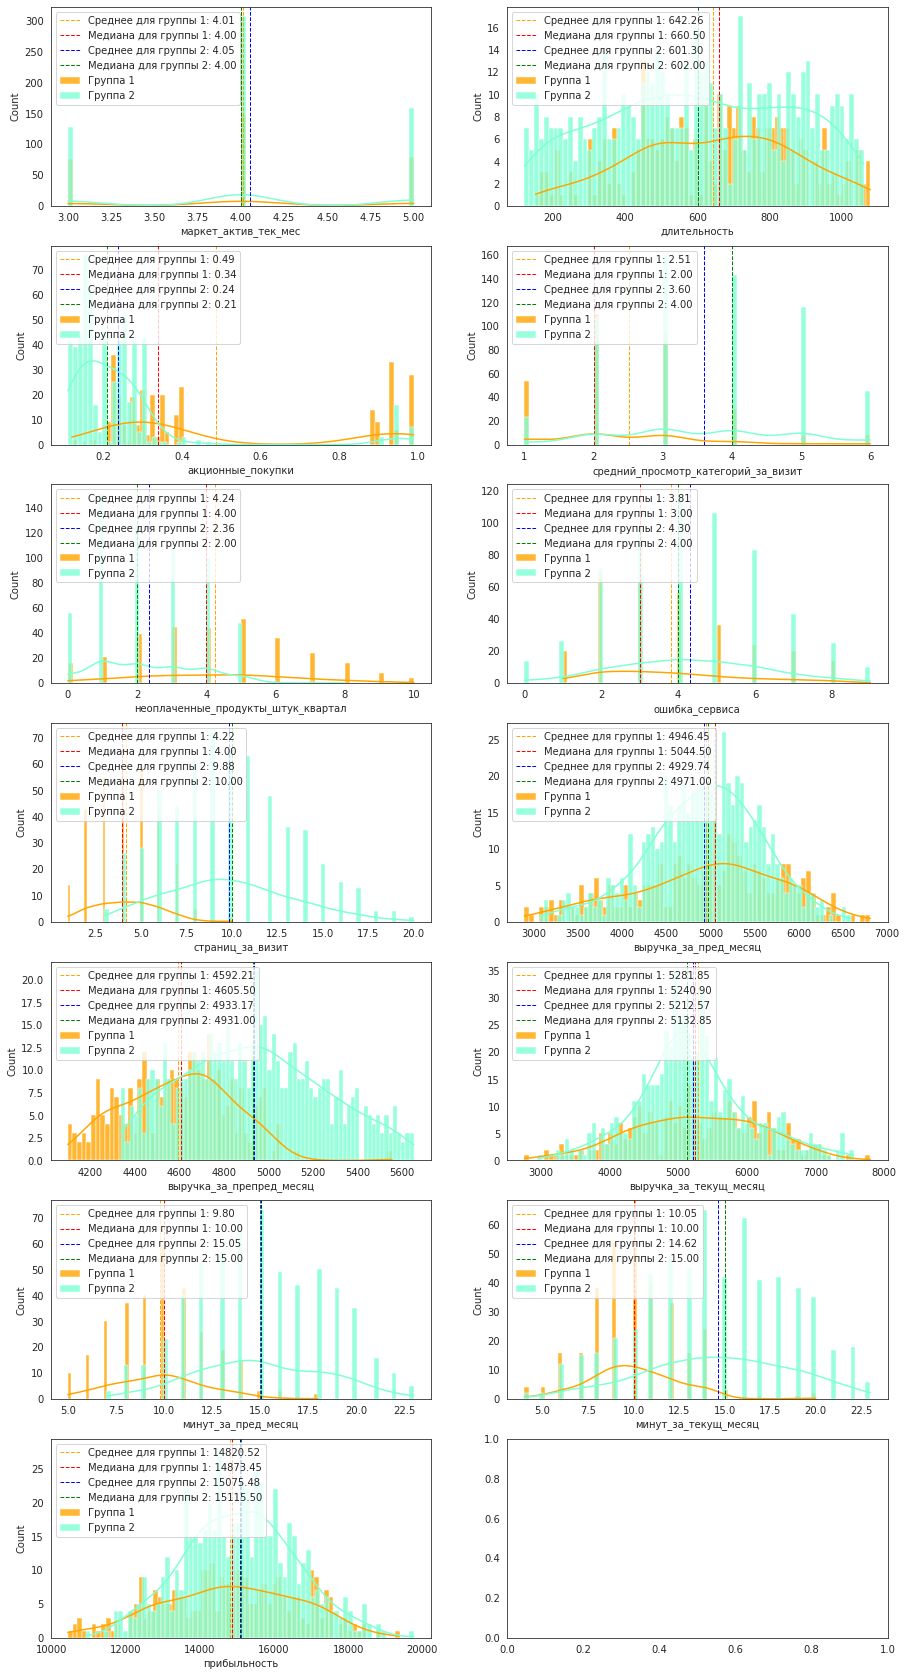

In [129]:
list_num = market_max_sales.drop(['id','вероятность','маркет_актив_6_мес'], axis=1)\
.select_dtypes(include=['int64','float64']).columns.tolist()
group_plot(market_min_aktiv,market_max_aktiv,7)

Построим столбчатые диаграммы для качественных признаков.

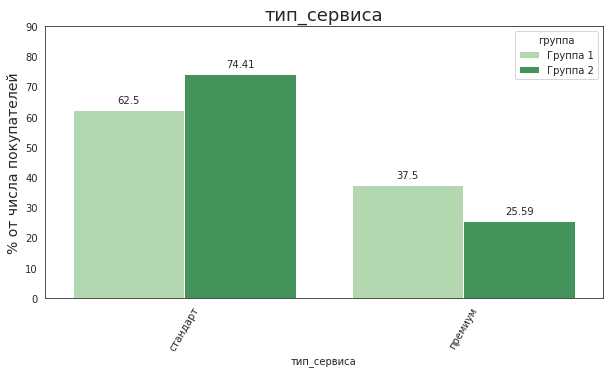

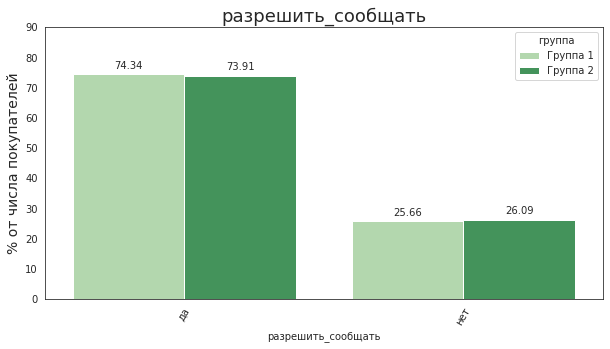

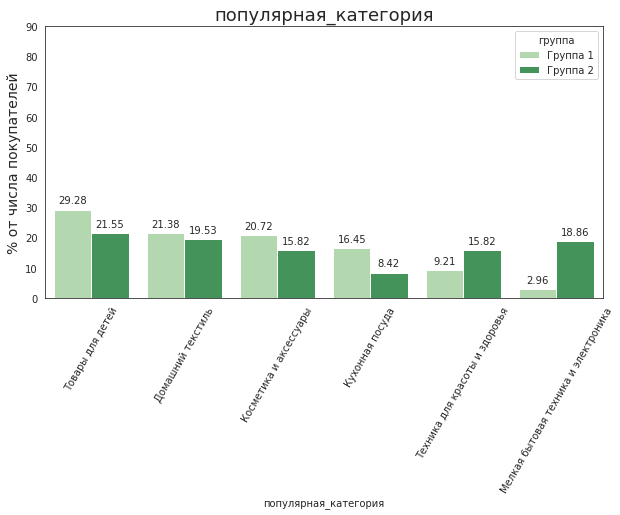

In [130]:
list_cat = ['тип_сервиса','разрешить_сообщать','популярная_категория'] 
group_bar(market_min_aktiv,market_max_aktiv)

Проанализируем изменение в выручке между периодами для разных категорий.

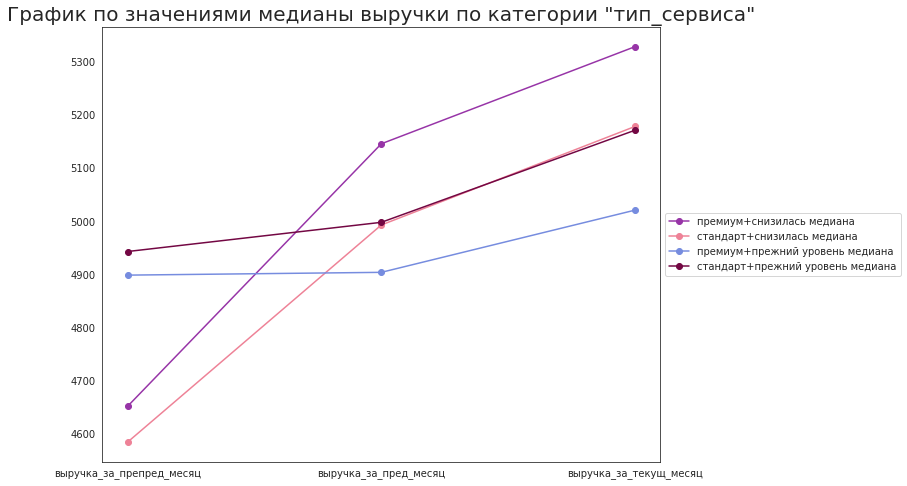

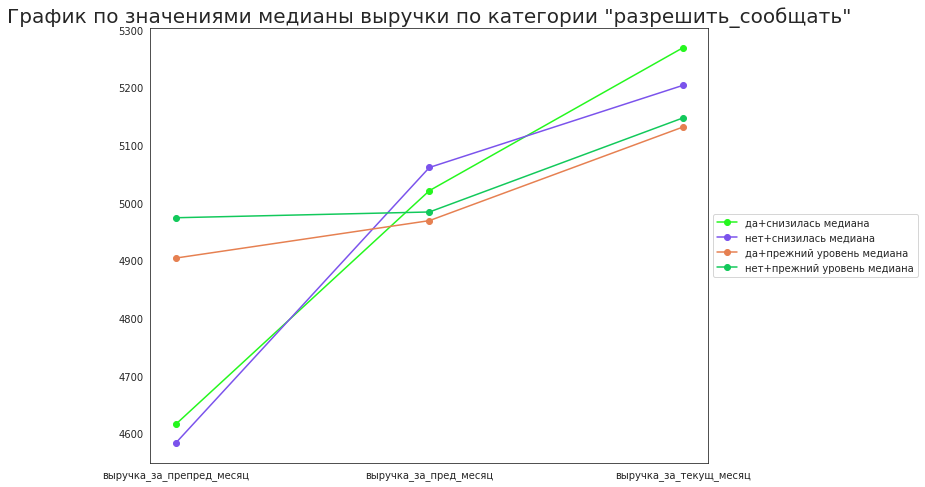

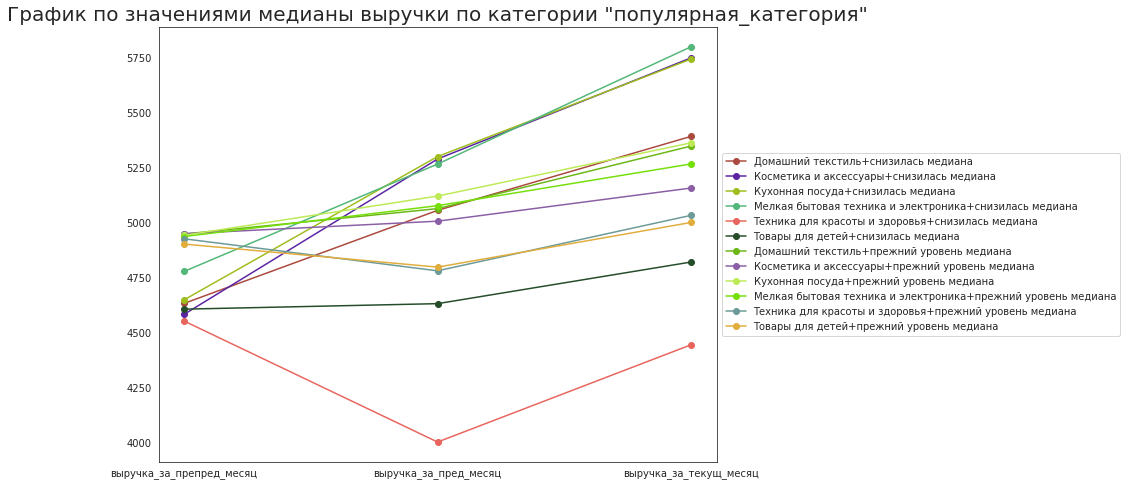

In [131]:
plot_sales(market_min_aktiv,market_max_aktiv)

Так как нет возможности переговорить с заказчиком, остается не ясным, почему показатель маркетинговых коммуникаций в текущем месяце сопоставим для групп. Он был сопоставим на всех этапах анализа. Возможно, что необходимость качественного уровня маркетинговых коммуникаций уже оценили и начали внедрять. Вполне понятно, что об акциях чаще людям приходит информация. Но стоит ввести и систему оповещения покупателей о новых товарах и производителях. Вполне возможно, что покупатели интересуются товарами только на основании поступившей информации посредством коммуникаций ввиду нехватки времени и не заходят на сайт в прочее время ради интереса. Есть вероятность, что сопоставимый уровень маркетинговых коммуникаций в текущем месяце привел к тому, что и выручка в текущем месяце у этих групп сопоставима. Особое внимание стоит опять обратить на раздел 'Техника для красоты и здоровья'.

<div style="border:solid green 2px; padding: 20px">
Вывод: на шаге 7 была выполнена сегментация покупателей. При этом использовались результаты моделирования и данные о прибыльности покупателей.
Анализ проводился для следующих групп покупателей:
    
- группа клиентов с максимальной долей покупок по акции и высокой вероятностью снижения покупательской активности;
- группа клиентов, которые покупают только технику, то есть товары с длинным жизненным циклом;
- группа клиентов, которые покупают товары из категории «Товары для себя»;
- группа клиентов с высокой вероятностью снижения покупательской активности и наиболее высокой прибыльностью;
- группа клиентов с высокой вероятностью снижения покупательской активности и меньшим уровнем маркетинговых коммуникаций за последние 6 месяцев
    
Были сделаны выводы о необходимости улучшения/расширения системы маркетинговых коммуникаций.


## Шаг. Общий вывод

<div style="border:solid green 2px; padding: 20px">
В рамках исследования необходимо было разработать решения для персонализации предложения постоянным клиентам с целью увеличения их покупательской активности для интернет-магазина «В один клик».
Данные для работы находятся в нескольких таблицах:

- market_file.csv
- market_money.csv
- market_time.csv
- money.csv

В рамках предобработки данных были проверены дубликаты, заменены значения столбцов на нижний регистр, изменены категориальные значения столбцов для дальнейшей работы.
На этапе исследовательского анализа данных были отобраны покупатели с непрерывной активностью в течение 3 месяцев. Были удалены данные с выбросом по выручке.
Для формирования пайплайнов были использованы следующие модели:
    
- KNeighborsClassifier()
- DecisionTreeClassifier()
- LogisticRegression()
- SVC()
При оценке моделей ориентир шел на метрику ROC-AUC, т.к. она наиболее подходит для несбалансированной модели.
В качестве инструмента автоматизированного поиска был выбран GridSearchCV. Он осуществляет перебор по сетке, все указанные значения гиперпараметров будут перебираться. Его лучше использовать при переборов небольших диапазонов значений.
Общий пайплайн показал выбор в пользу модели SVC() с показателями:
    
- С = 1
- kernel = 'rbf'
- preprocessor__num - StandardScaler()

Метрика лучшей модели на тренировочной выборке: 0.9074669322214778
Метрика ROC-AUC на тестовой выборке: 0.9166363305424099
Accuracy: 0.907
F1-score: 0.866
    
Применение SelectKBest() показало важное значение 8 признаков.

Исследование важности признаков показало, что наиболее важными являются:
    
- среднее количество страниц, которые просмотрел покупатель за один визит на сайт за последние 3 месяца
- значение времени, проведённого на сайте, в минутах (предыдущий месяц)
- значение времени, проведённого на сайте, в минутах (текущий месяц)
- среднемесячное значение маркетинговых коммуникаций компании, которое приходилось на покупателя за последние 6 месяцев (значение показывает, какое число рассылок, звонков, показов рекламы и прочего приходилось на клиента)

Наименее значимые признаки расходятся при использовании различных методов.

Были сделаны выводы о том, что доля акционных покупок очень серьезно влияет на покупательскую активность (покупатели, склонные с акционным покупками, приносят прибыли не меньше, чем прочие покупатели). Необходимо рассмотреть возможность продолжения/расширения акций. Особенно в категории 'техника для красоты и здоровья'. Также необходимо увеличить количество маркетинговых коммуникаций (если система маркетинговых коммуникаций, учитывая количество коммуникаций текущего месяца, еще не пересмативалась)
